In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils.config import setup_environment
from utils.loader import load
from utils.cleaner import simplify_position, clean_data 
from utils.plot import plot_attribute_distribution, plot_box_by_position, plot_corr_matrix, plot_height_weight, plot_position_scatter_markers, plot_goals_distribution, plot_league_mean_goals, plot_team_med_ovr_vs_goals, plot_team_med_ovr_vs_loss, plot_team_med_ovr_vs_win_rate, plot_team_med_ovr_vs_non_defeat_rate, parallel_topk_by_position, baseline_plot, plot_formation, plot_ovr_between_nationality, plot_ovr_between_league
from utils.common import POS

setup_environment()

# Fantastic Squad

Build a best 10 players team (exclude GK) based on match and player performance on 2024-2025 big five leagues

Data source: https://www.football-data.co.uk

https://www.kaggle.com/datasets/flynn28/eafc26-player-database

Cleaned by standardizing team name, removed useless columns. 

In [2]:
df_players = load("players.csv")
df_matches = load("matches.csv")

Loaded: (2543, 56) from /Users/dwertyu/Documents/Fantastic-Squad/data/players.csv
Loaded: (1752, 8) from /Users/dwertyu/Documents/Fantastic-Squad/data/matches.csv


In [3]:
df_players, df_matches = clean_data(df_players, df_matches)

## EDA

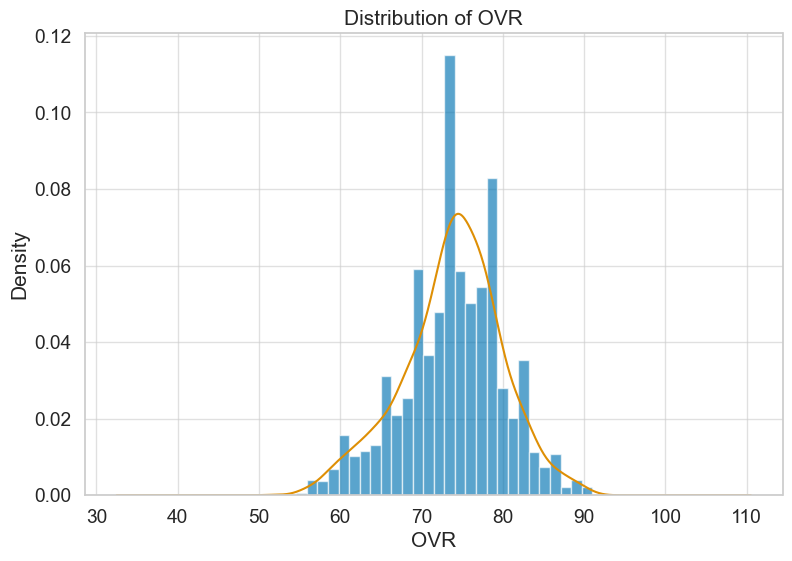

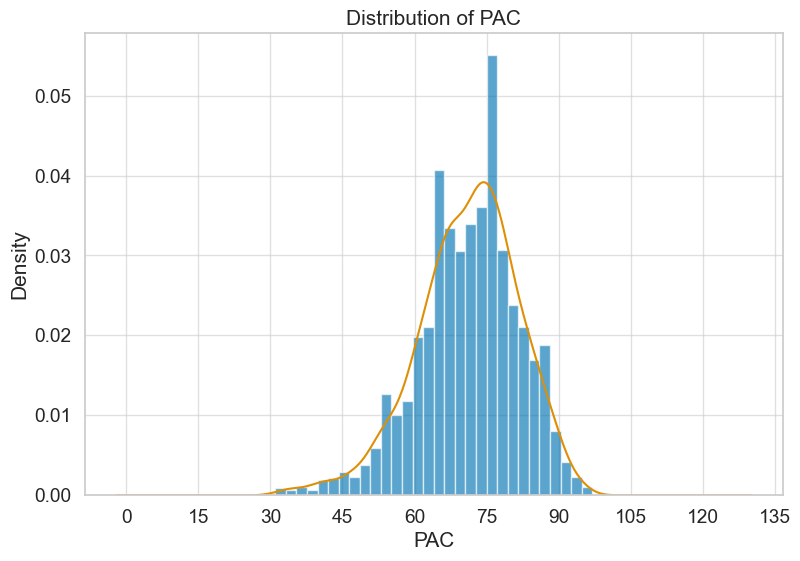

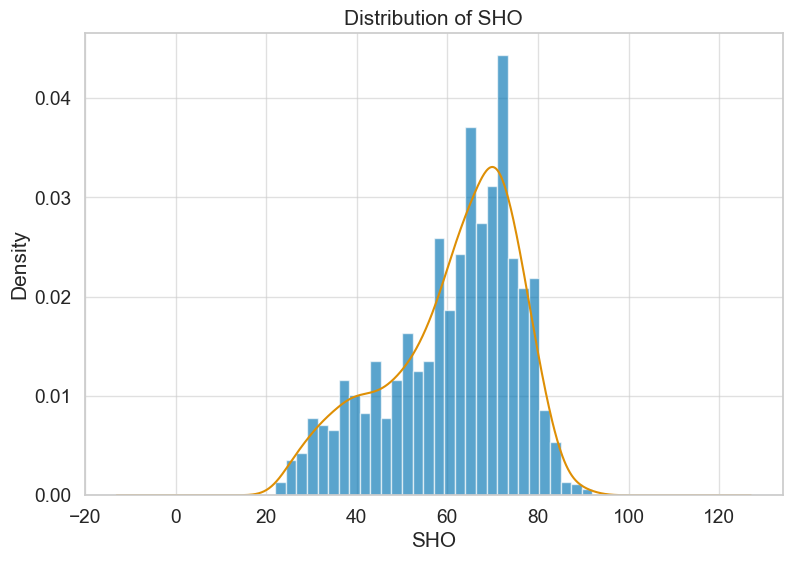

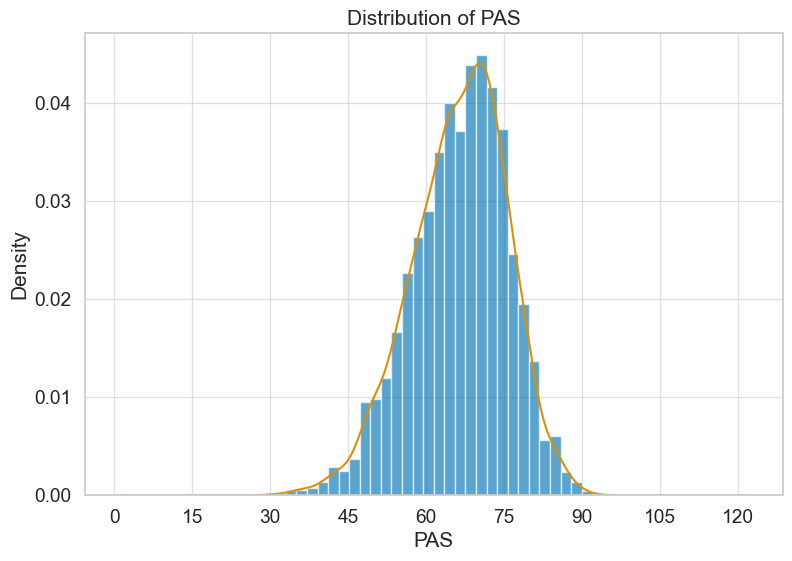

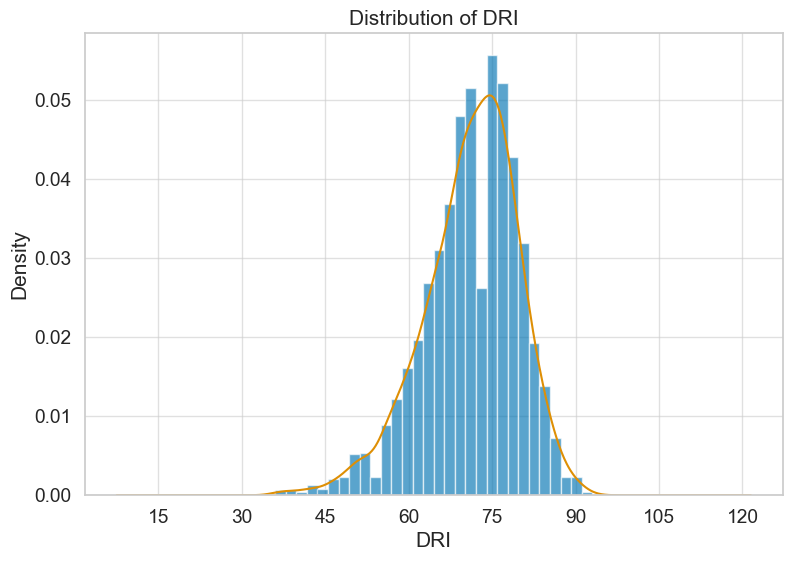

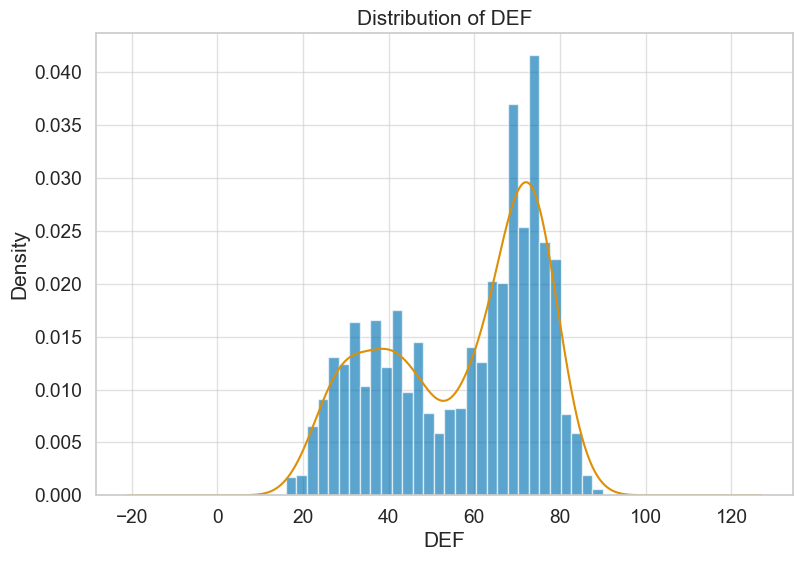

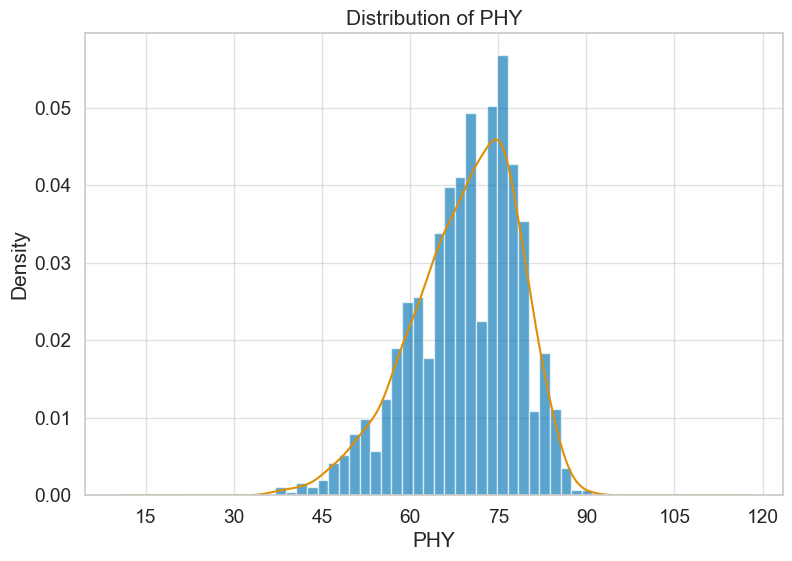

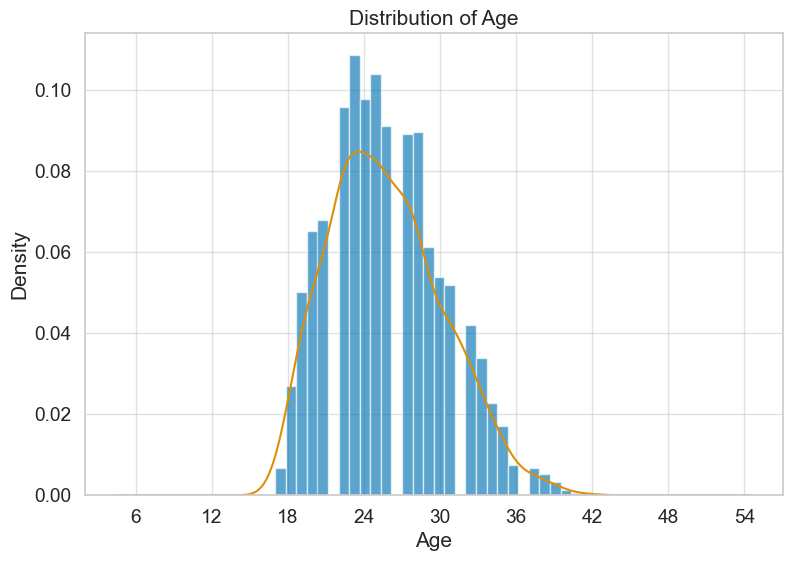

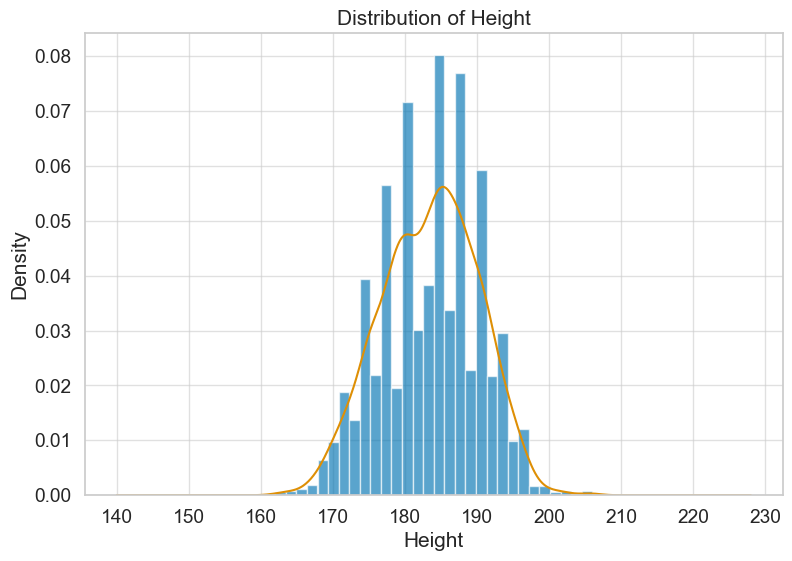

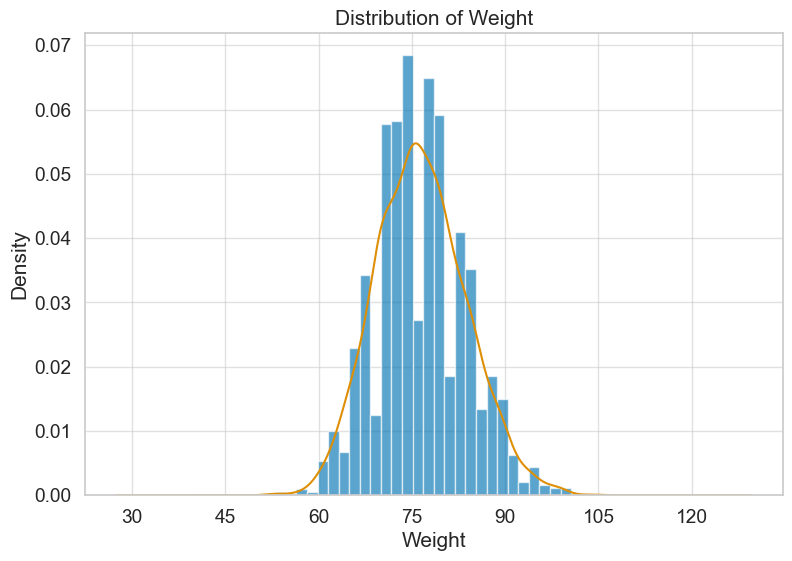

In [4]:
plot_attribute_distribution(df_players)

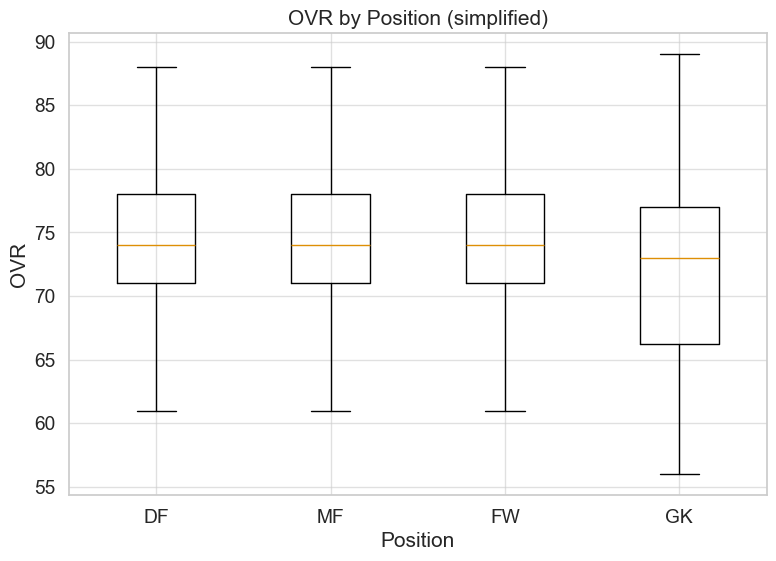

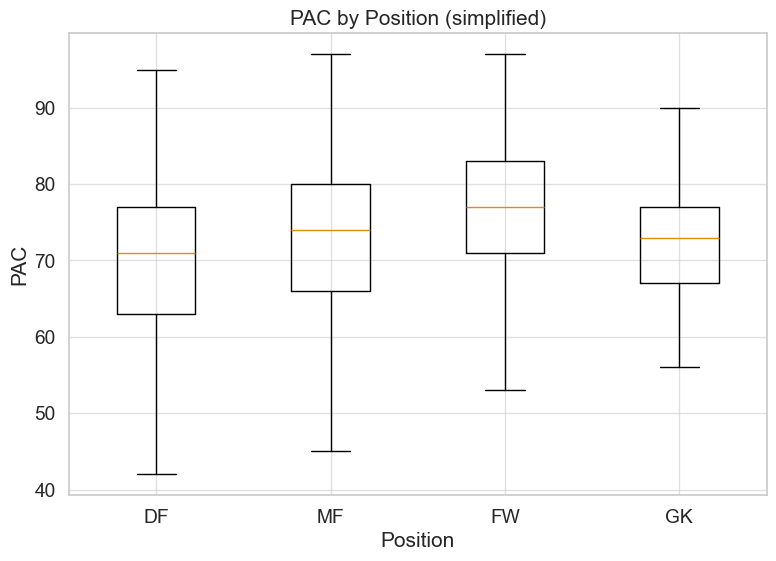

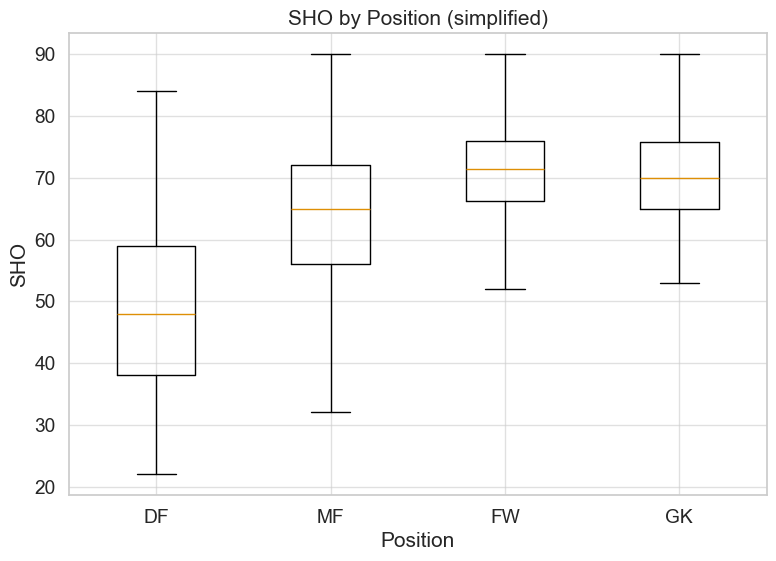

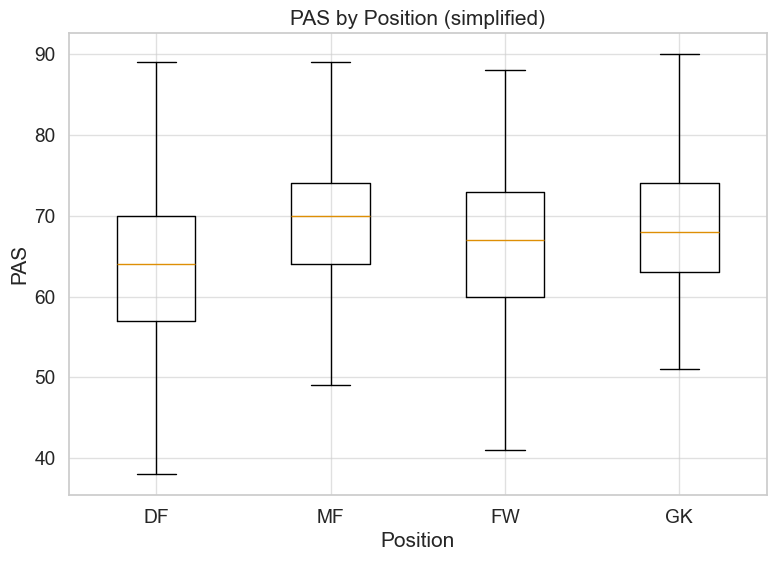

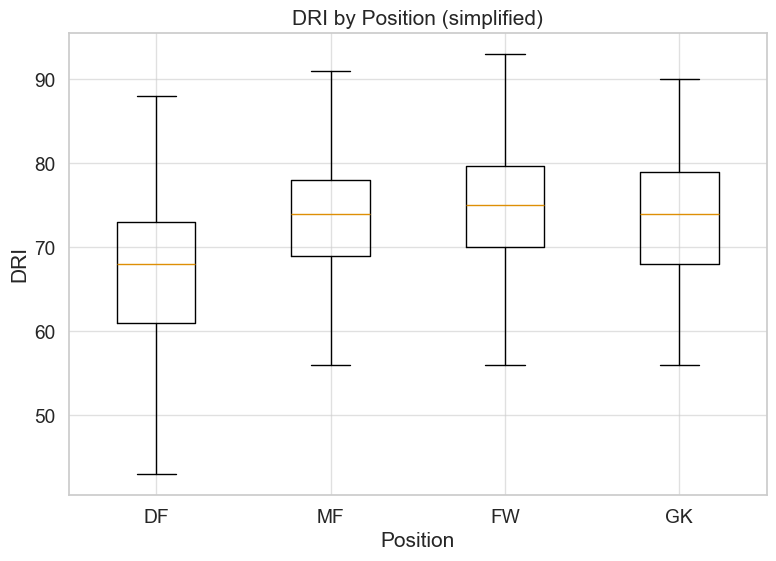

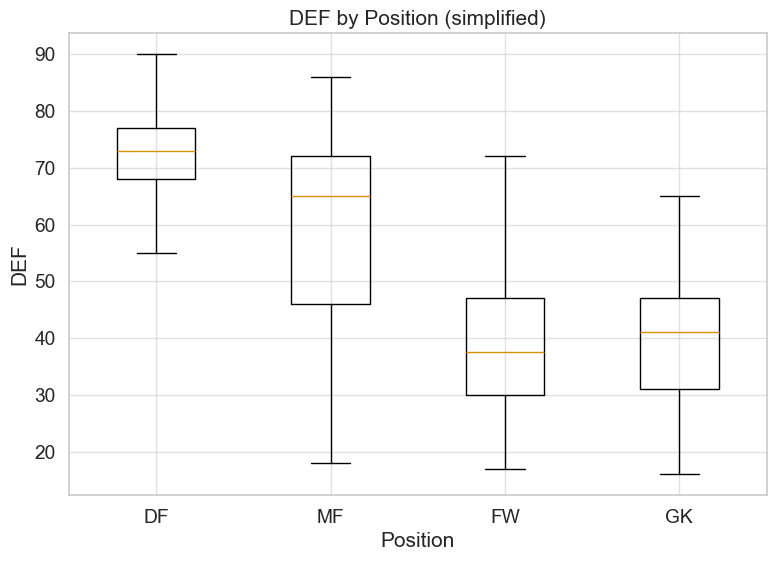

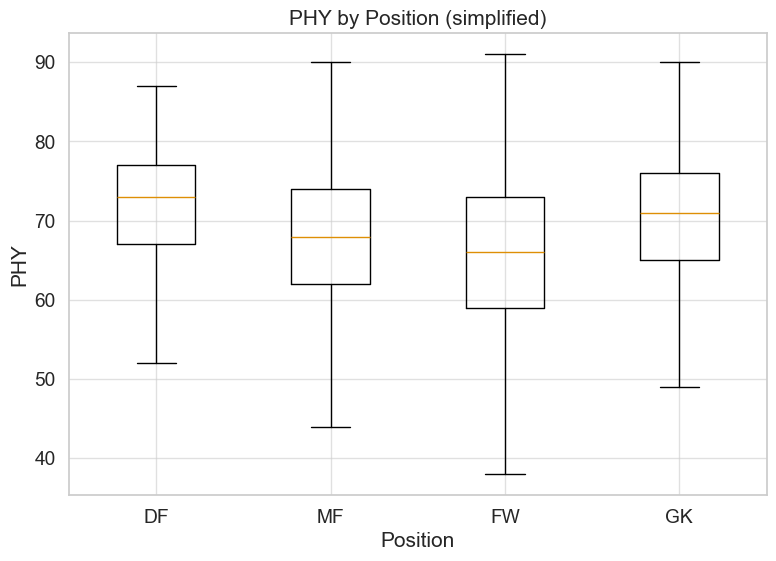

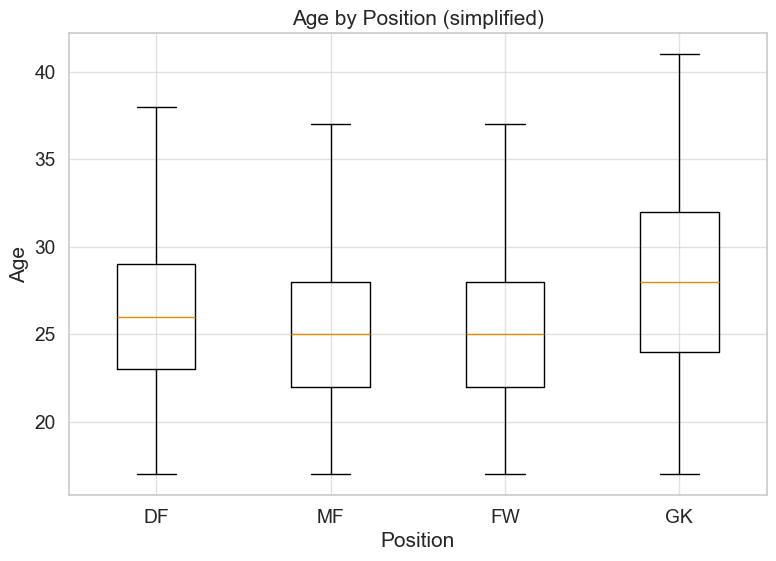

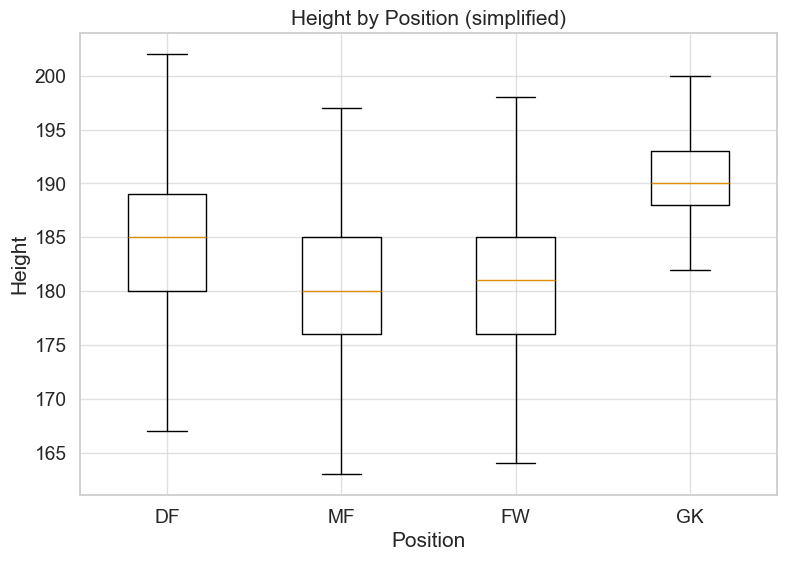

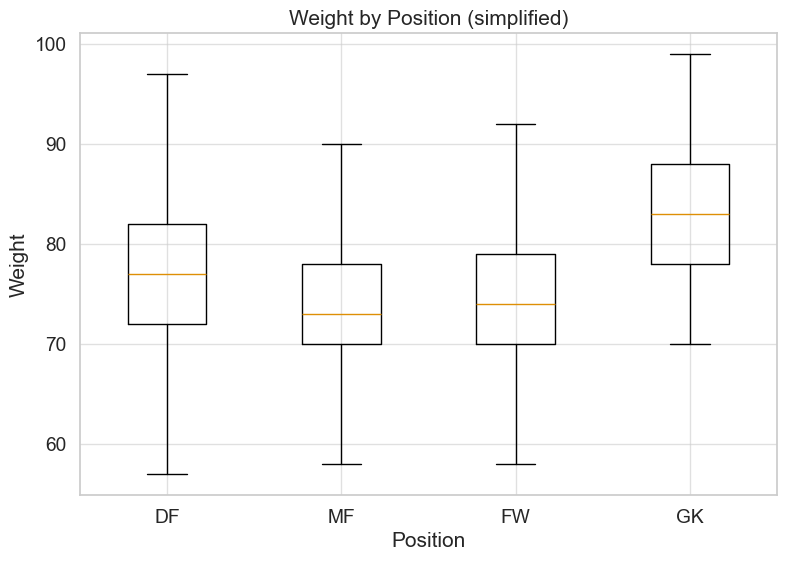

In [5]:
plot_box_by_position(df_players)

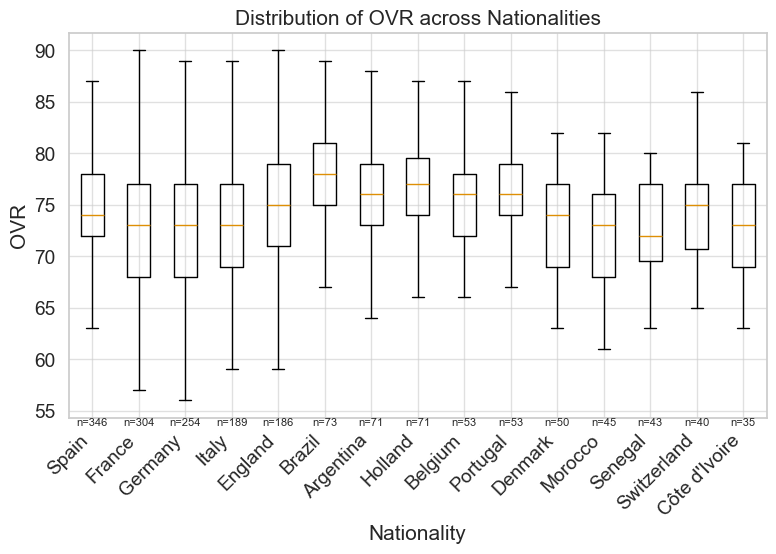

In [6]:
plot_ovr_between_nationality(df_players)

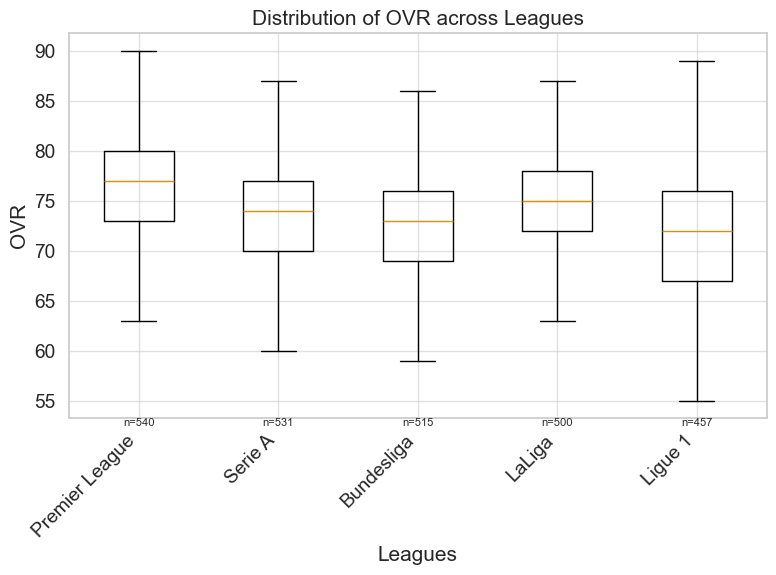

In [7]:
plot_ovr_between_league(df_players)

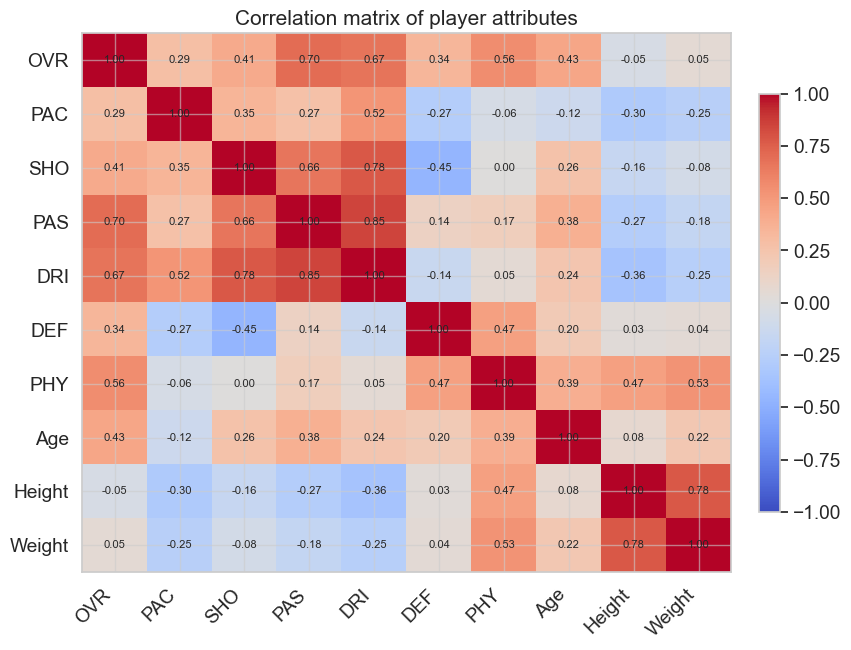

In [8]:
plot_corr_matrix(df_players)

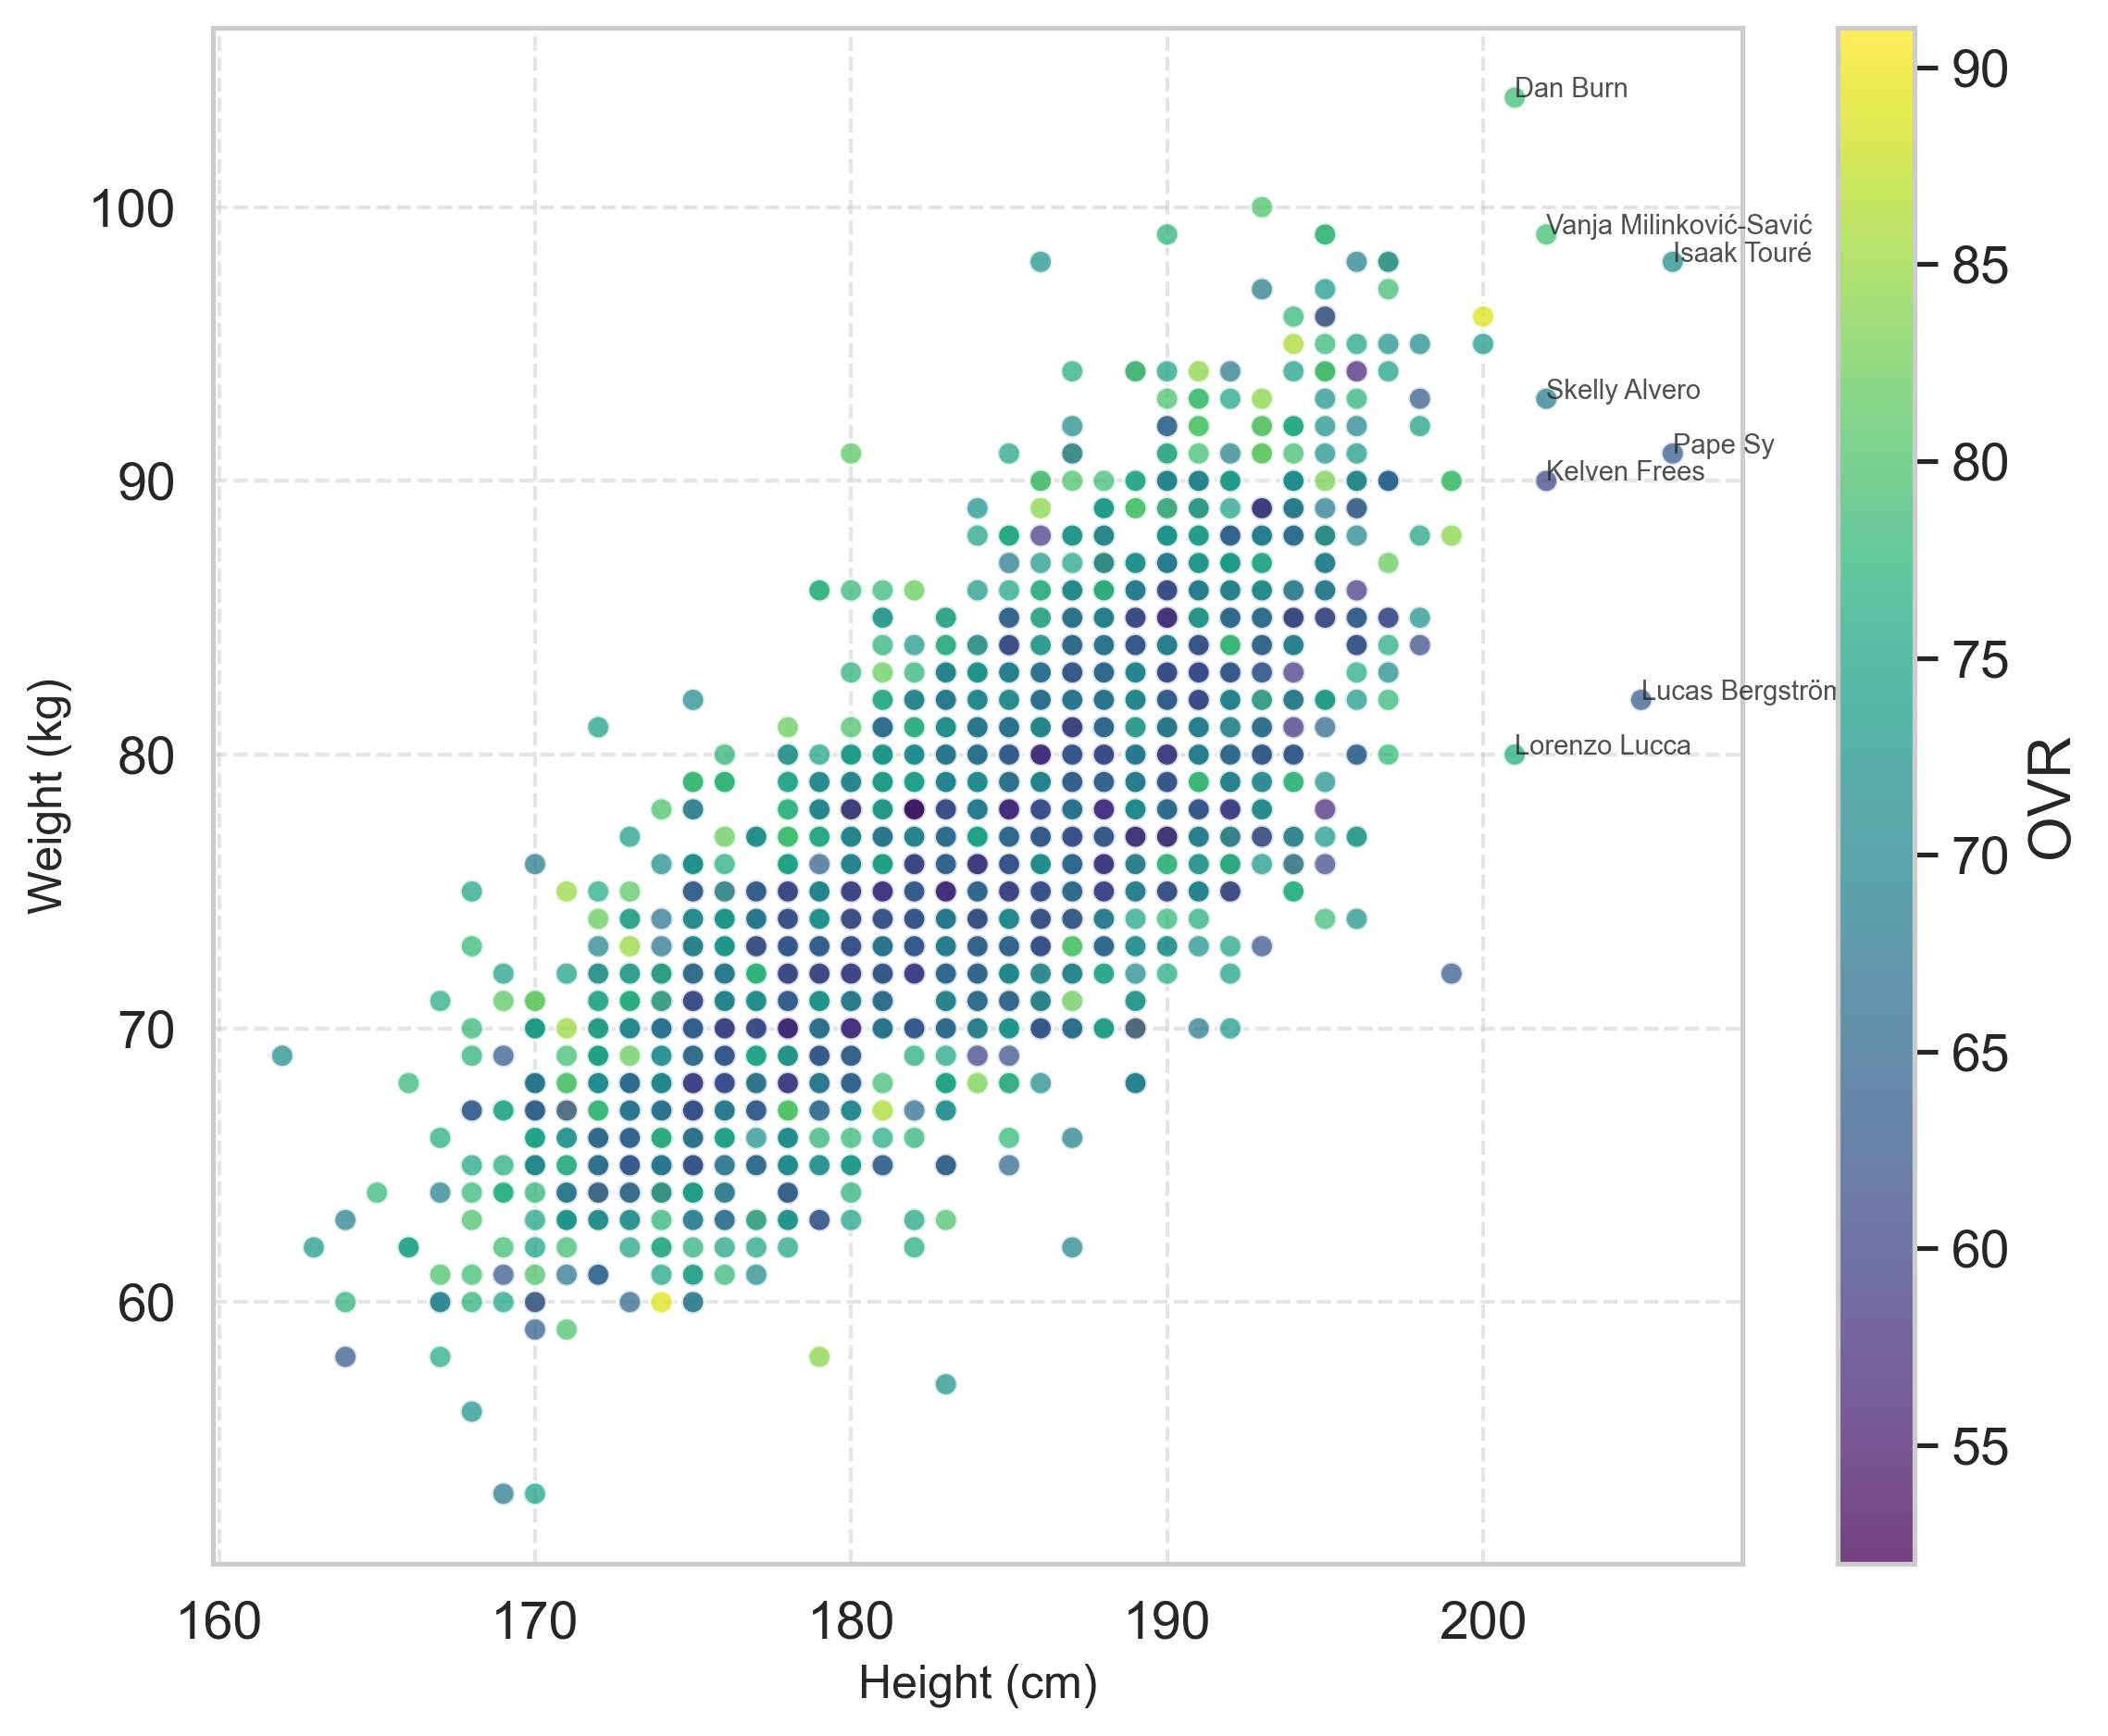

In [9]:
plot_height_weight(df_players)

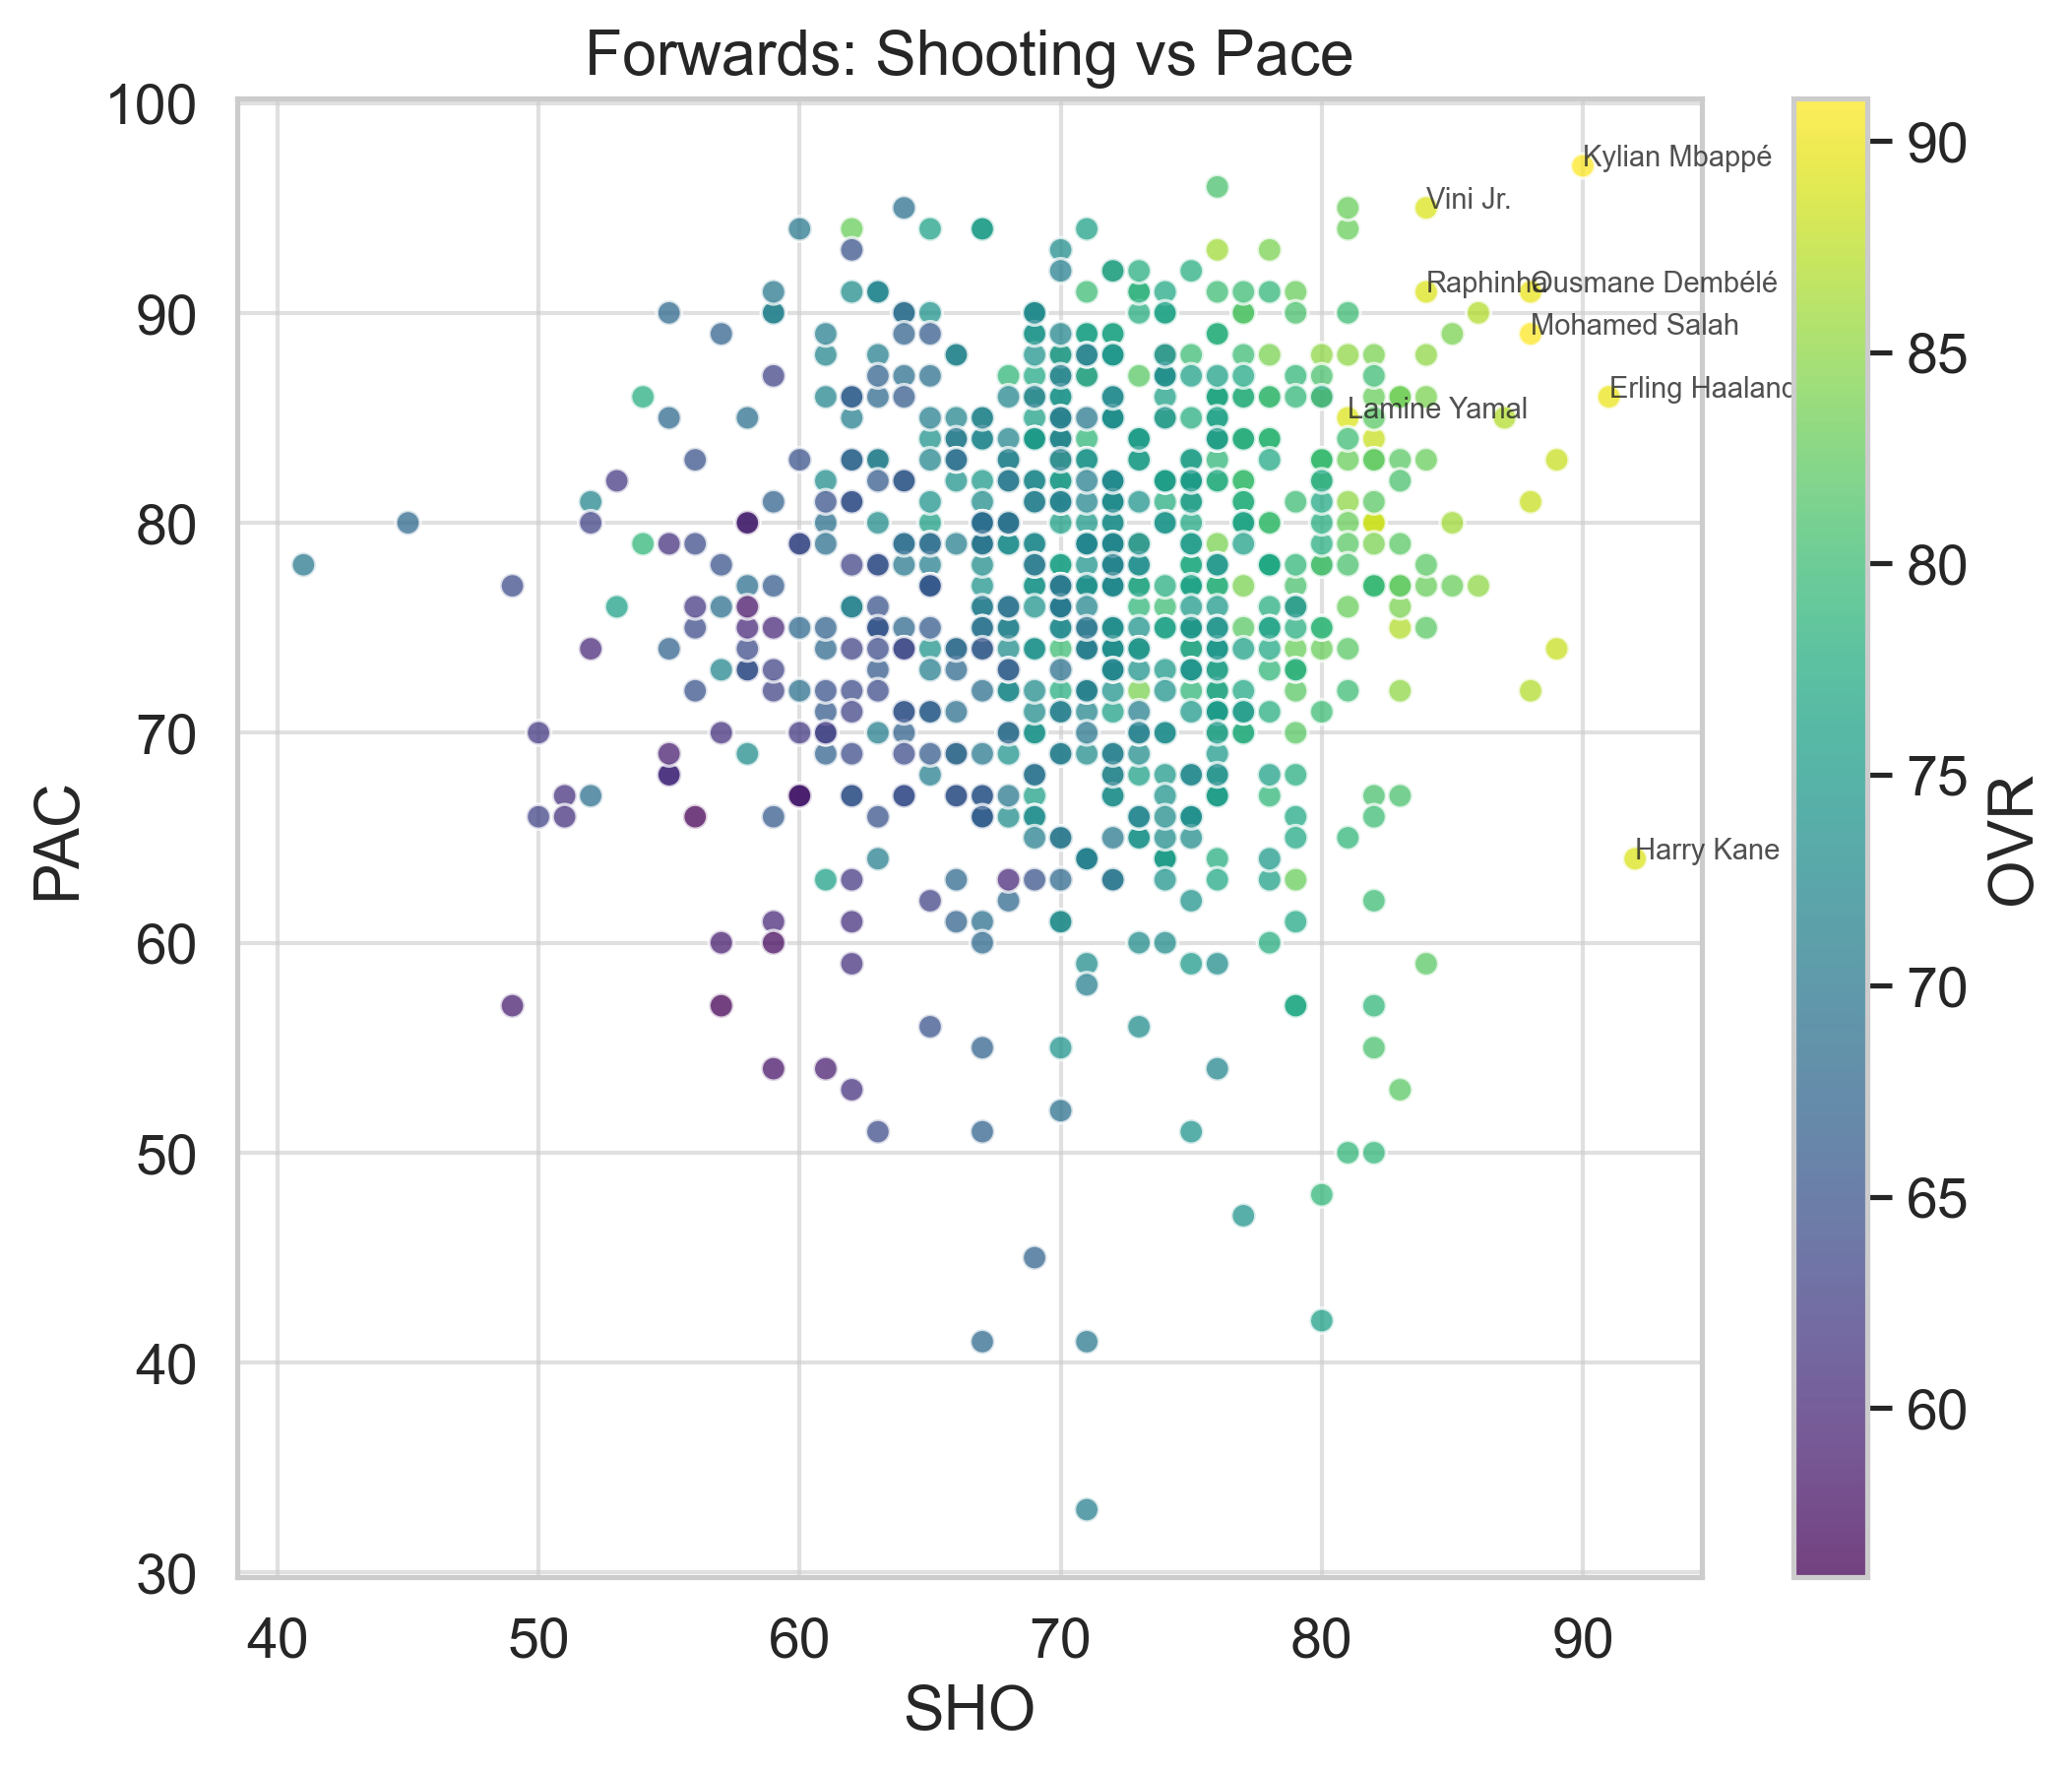

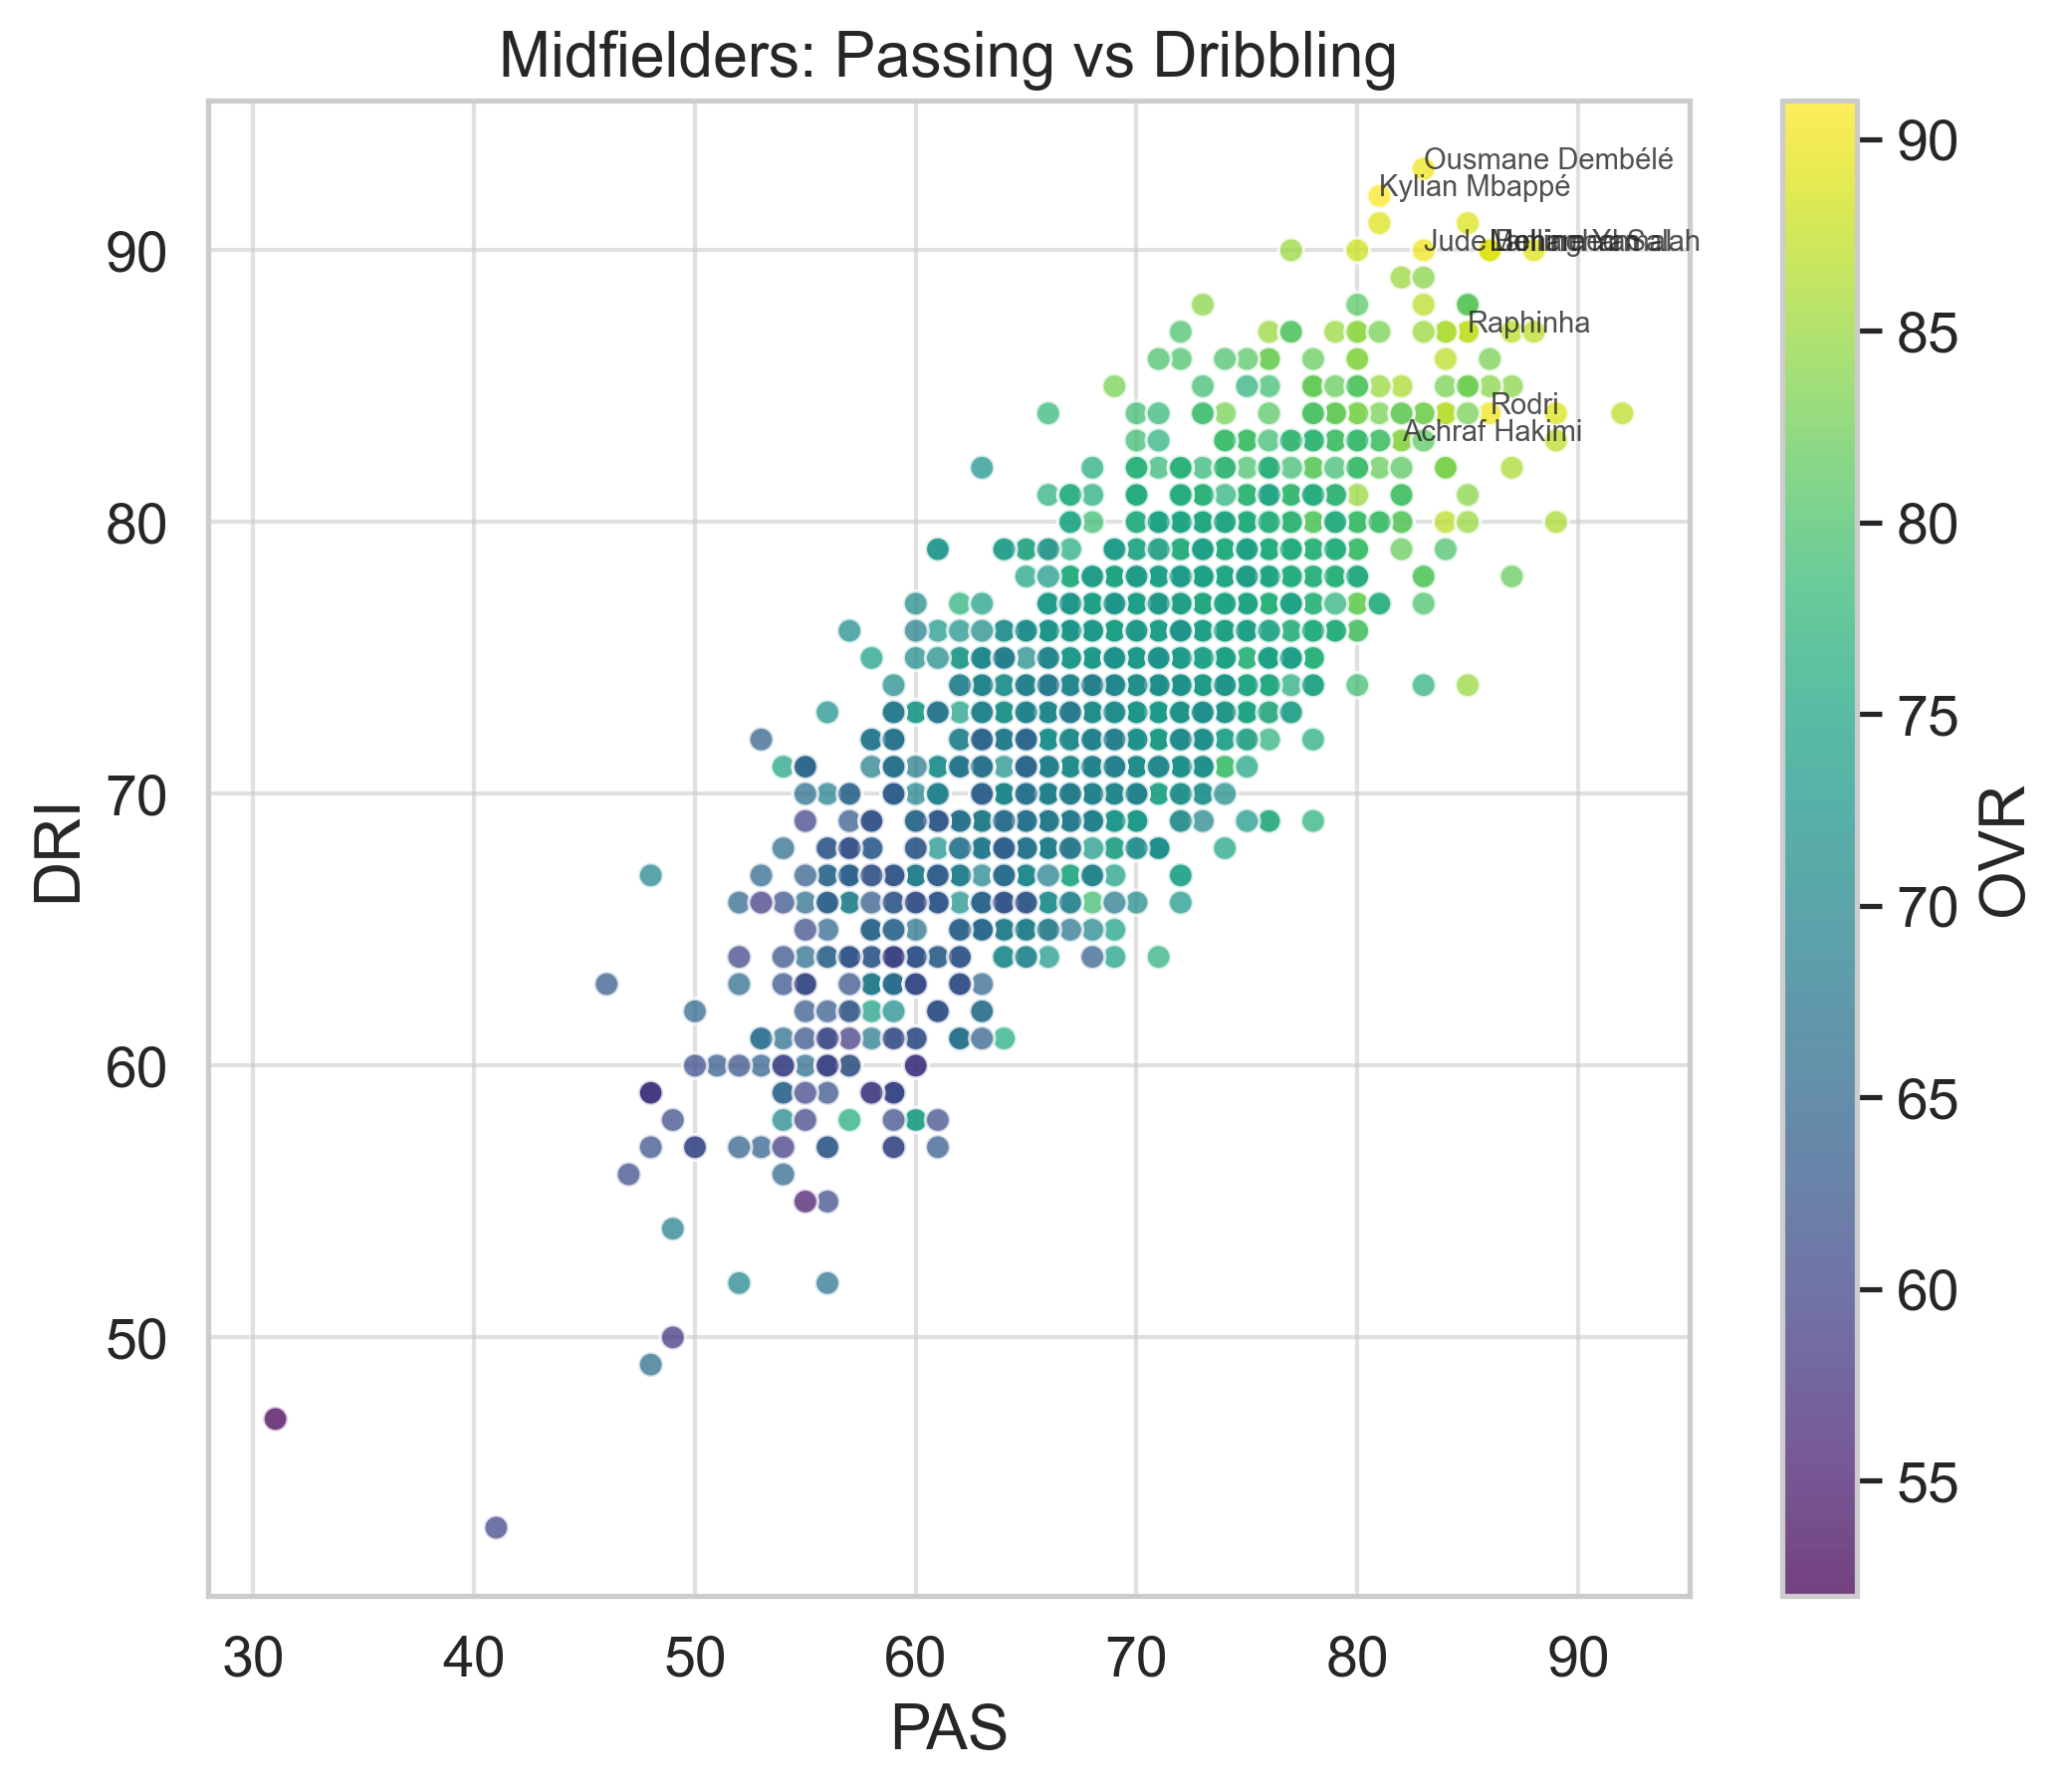

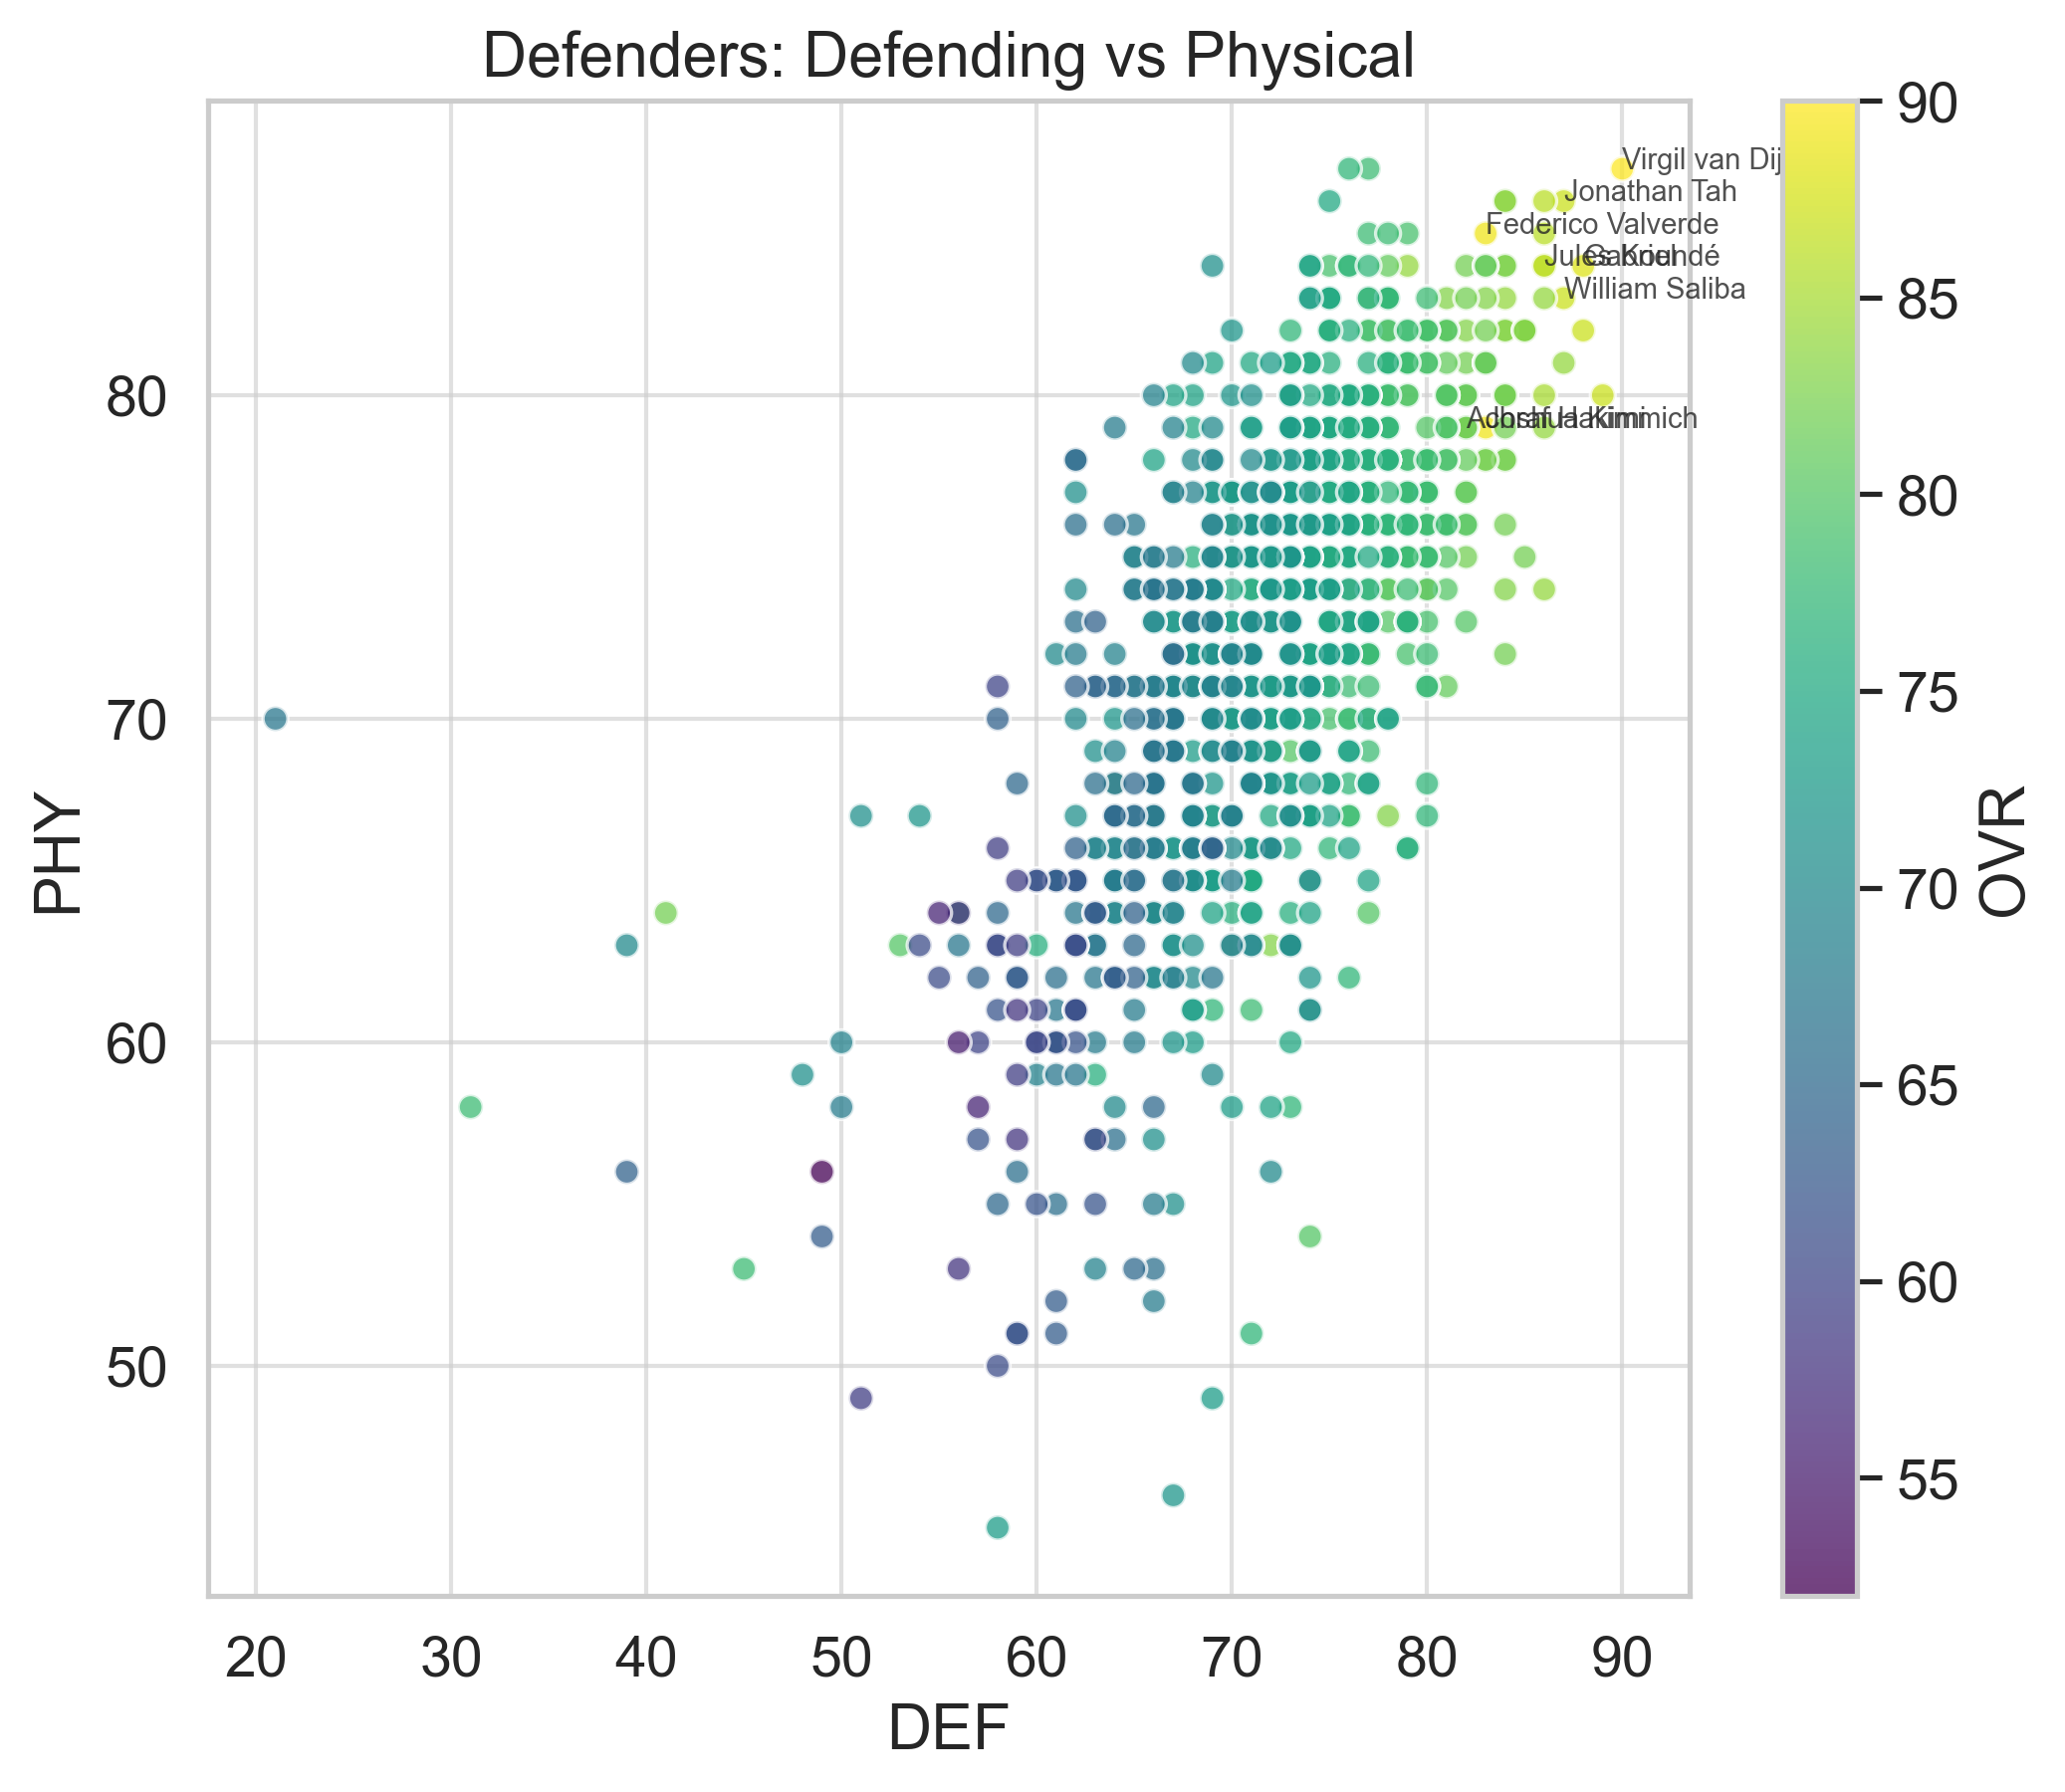

In [10]:
plot_position_scatter_markers(df_players)

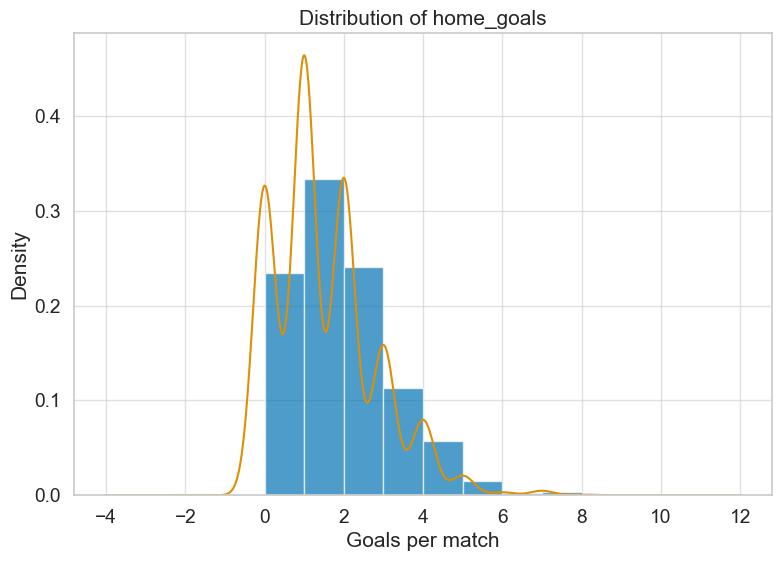

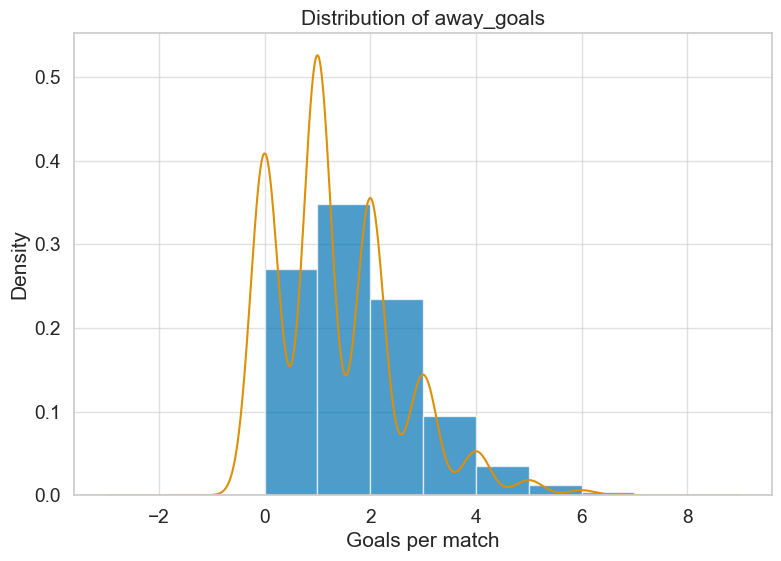

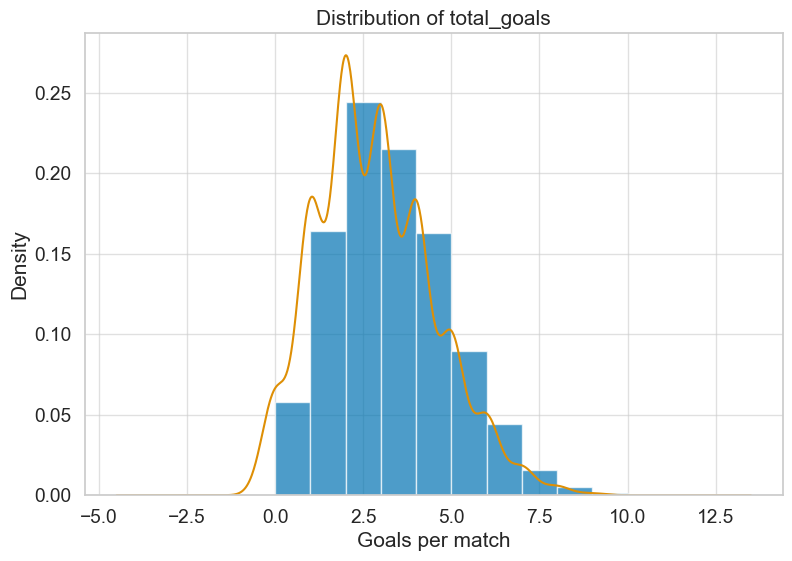

In [11]:
plot_goals_distribution(df_matches)

/Users/dwertyu/Documents/Fantastic-Squad/utils/plot.py:212: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(stats.index, rotation=45, ha='right')


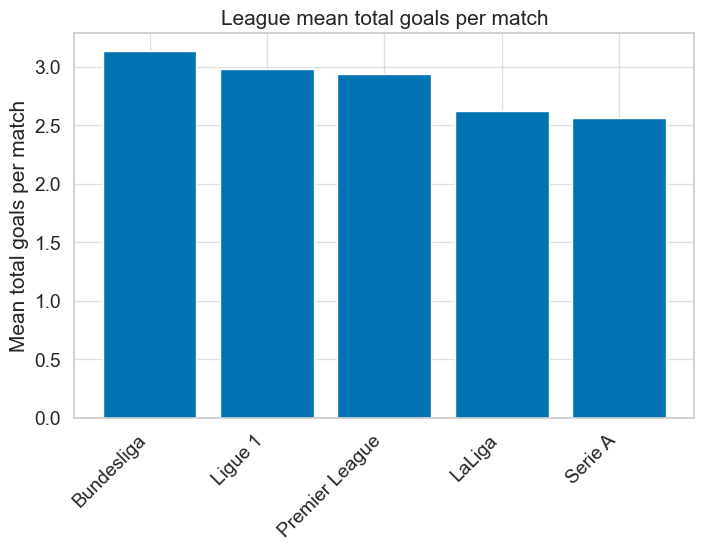

In [12]:
plot_league_mean_goals(df_matches)

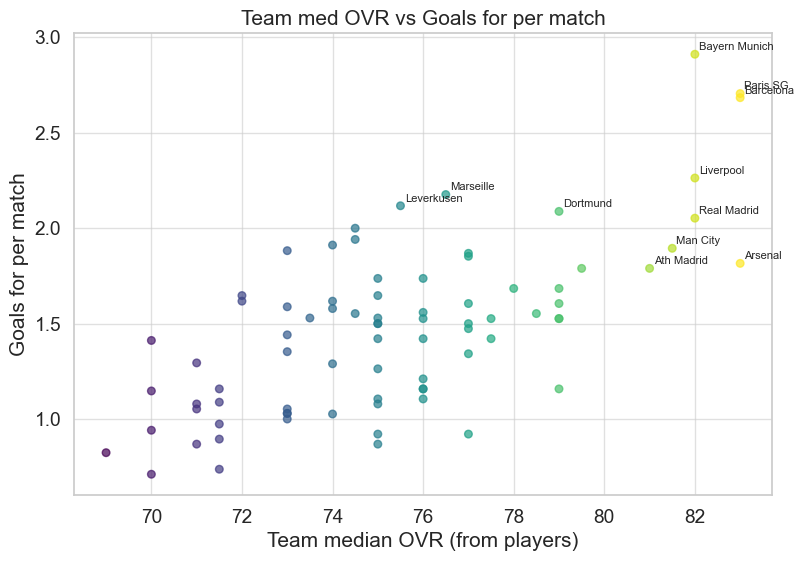

In [13]:
plot_team_med_ovr_vs_goals(df_players, df_matches)

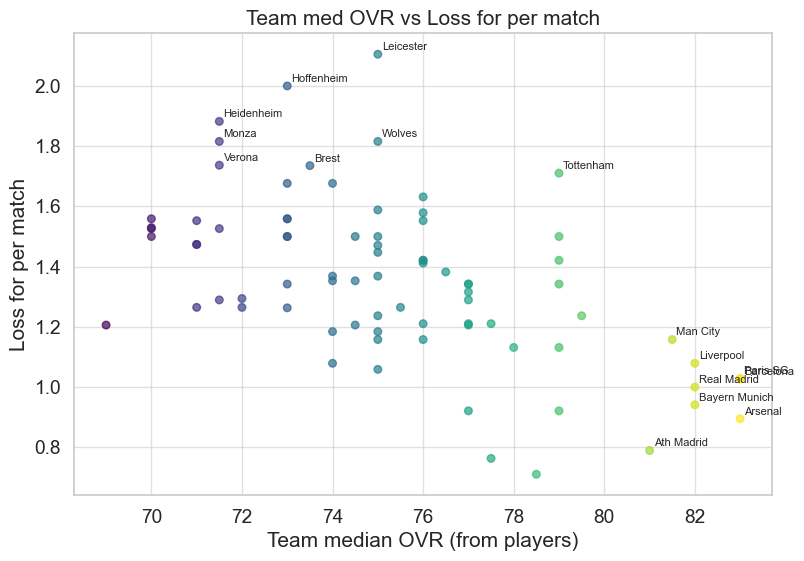

In [14]:
plot_team_med_ovr_vs_loss(df_players, df_matches)

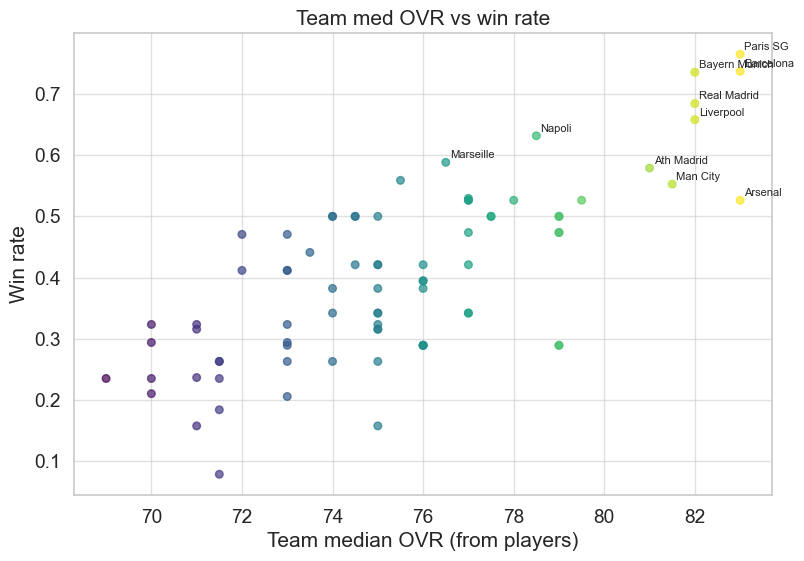

In [15]:
plot_team_med_ovr_vs_win_rate(df_players, df_matches)

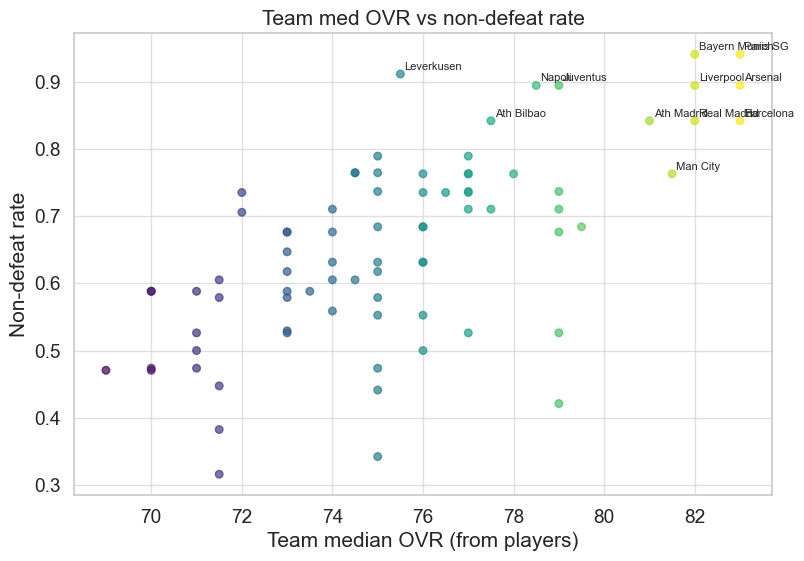

In [16]:
plot_team_med_ovr_vs_non_defeat_rate(df_players, df_matches)

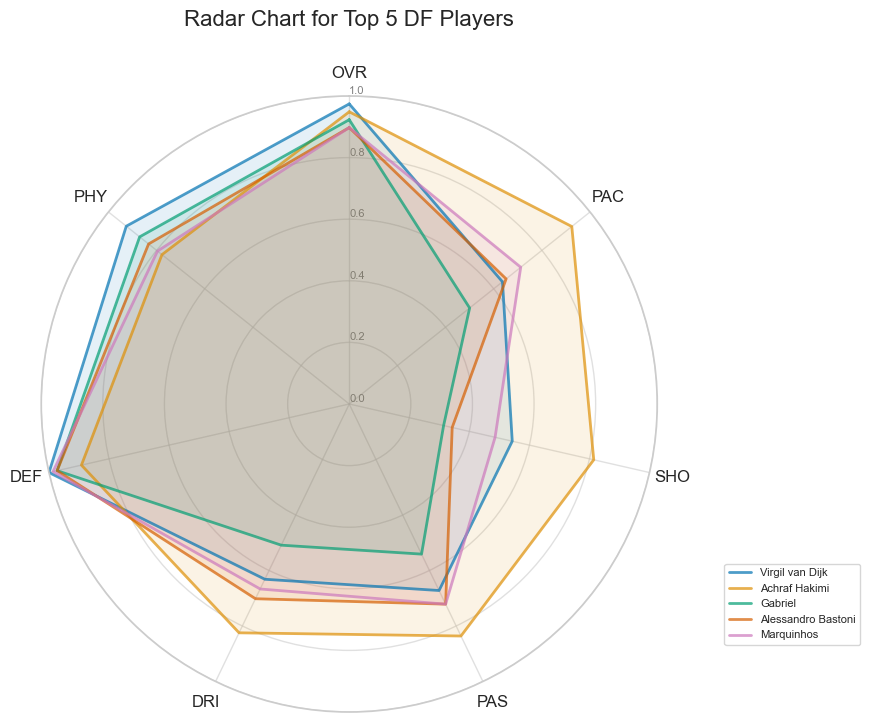

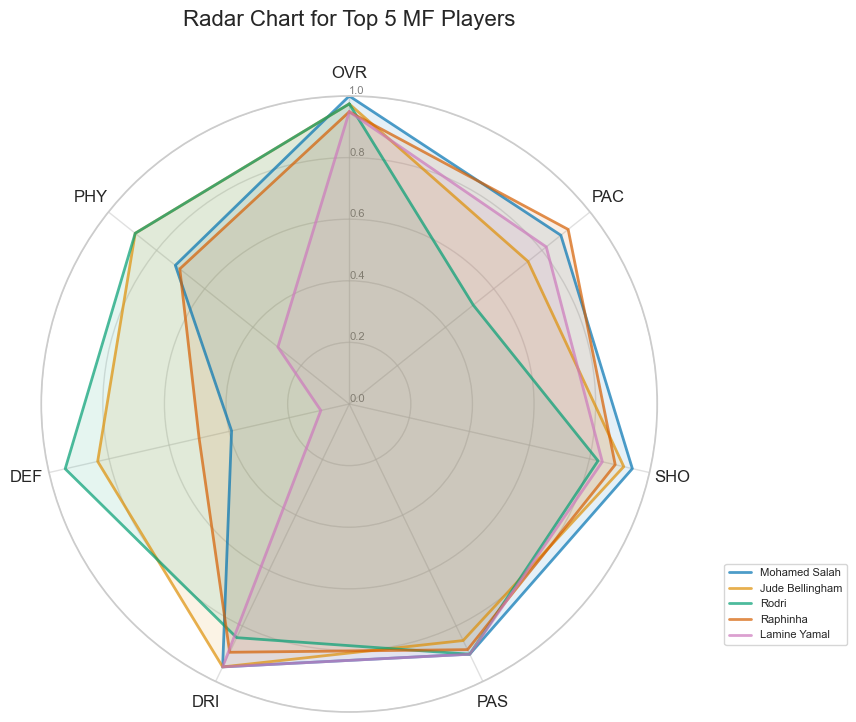

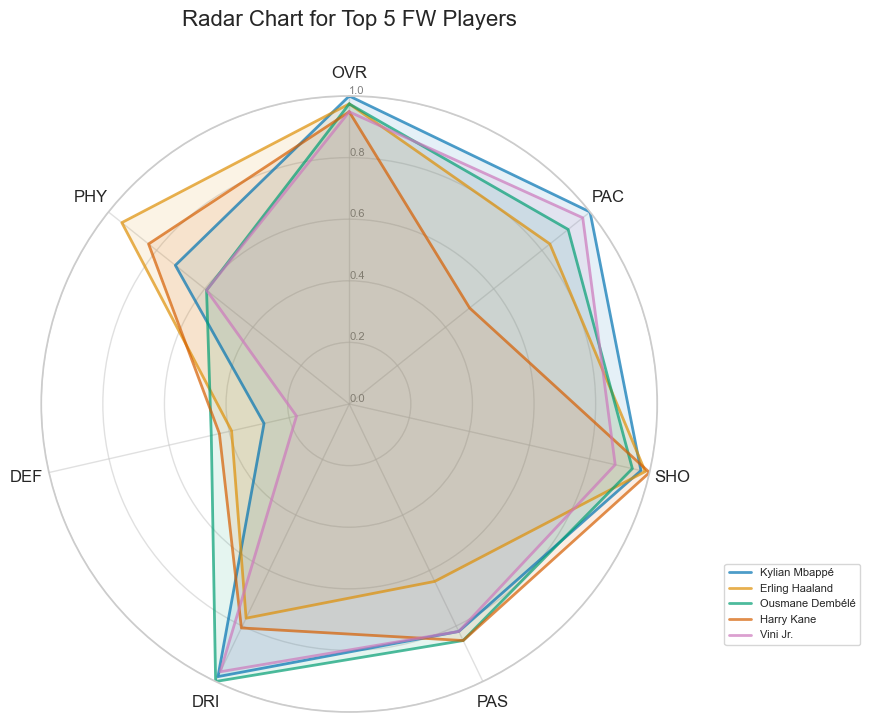

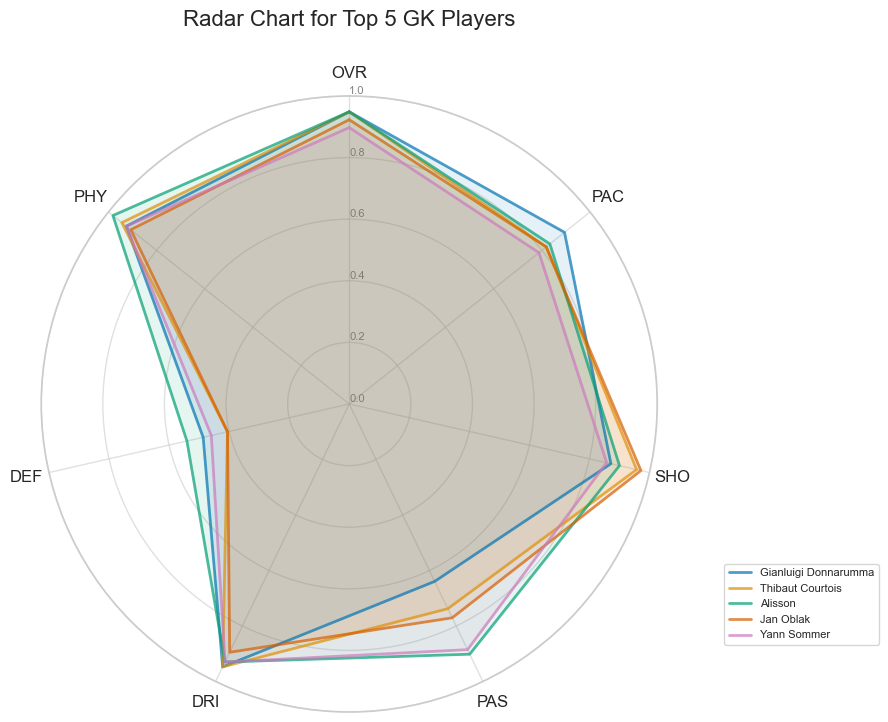

In [17]:
parallel_topk_by_position(df_players)

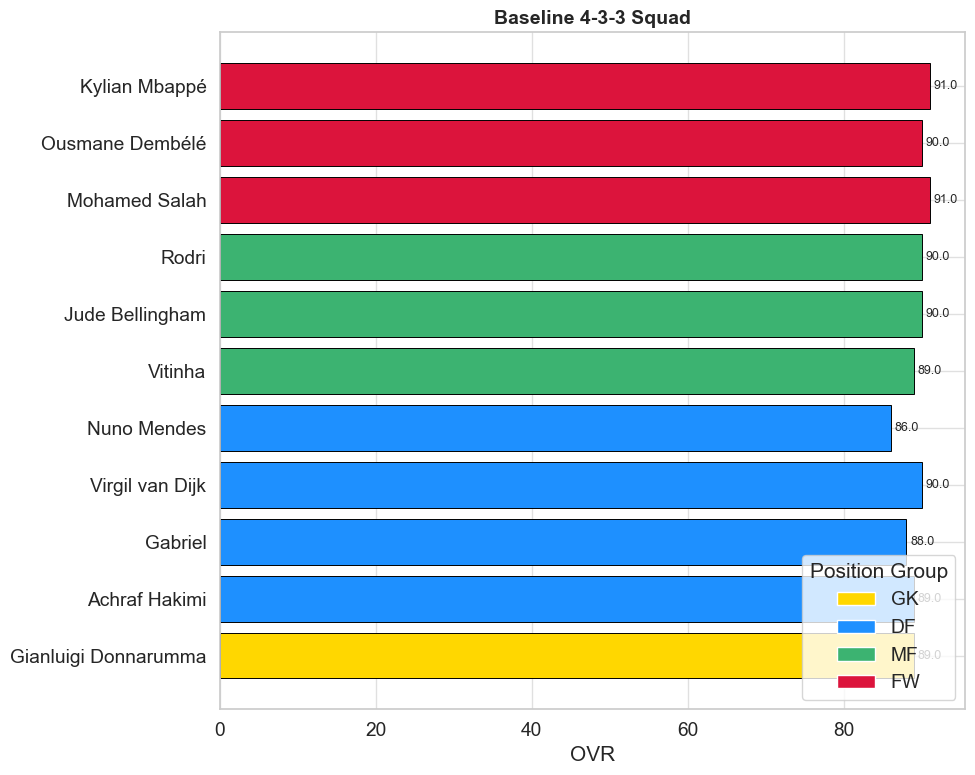

In [18]:
baseline_plot(df_players)

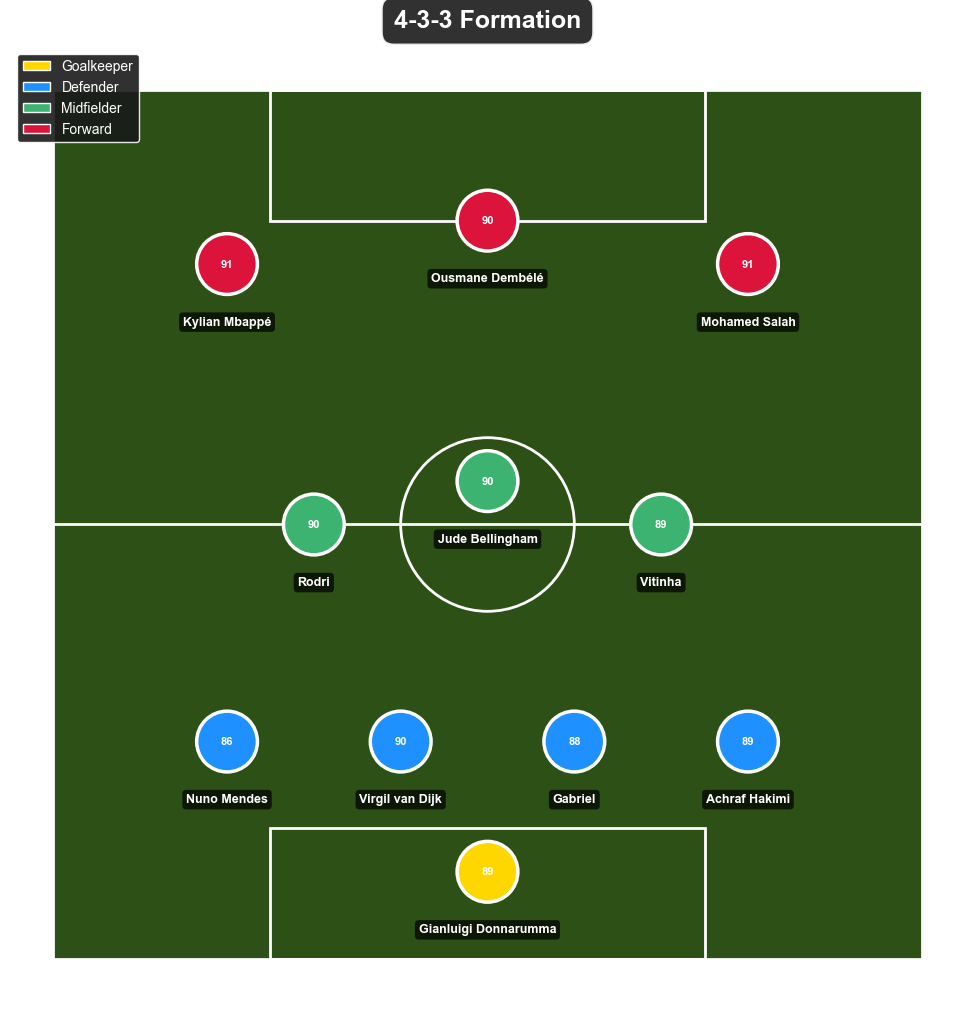

In [19]:
plot_formation(df_players)

## Model

In [20]:
LATENT_FEATURES = {
    "FW": {
        "finishing": [
            "Finishing", "Shot Power", "Composure", "Positioning"
        ],
        "pace": [
            "Sprint Speed", "Acceleration", "Agility"
        ]
    },
    "MF": {
        "creativity": [
            "Vision", "Short Passing", "Long Passing", "Ball Control"
        ],
        "box_to_box": [
            "Stamina", "Dribbling", "Balance", "Reactions"
        ],
        "def_cover": [
            "Interceptions", "Def Awareness", "Stamina"
        ]
    },
    "DF": {
        "positioning": [
            "Def Awareness", "Interceptions", "Reactions"
        ],
        "duel": [
            "Strength", "Jumping", "Heading Accuracy"
        ],
        "tackling": [
            "Standing Tackle", "Sliding Tackle", "Aggression"
        ]
    }
}

In [21]:
def build_team_latent(team, df_players, pos, K):
    team_players = df_players[df_players["Team"] == team]

    exploded = team_players.explode("all")
    players_idx = exploded[exploded["all"] == pos].index
    players = team_players.loc[players_idx]

    if len(players) == 0:
        return None

    players = players.sort_values("OVR", ascending=False).head(K)

    latent = {}
    for name, feats in LATENT_FEATURES[pos].items():
        latent[f"{pos}_{name}"] = players[feats].mean().mean()

    return latent


In [22]:
def compute_team_features(team, df_players, mode=0):
    fw = build_team_latent(team, df_players, "FW", 5)
    mf = build_team_latent(team, df_players, "MF", 6)
    df = build_team_latent(team, df_players, "DF", 7)

    if fw is None or mf is None or df is None:
        return None

    features = {}

    if mode == 0:
        # attack side
        features["FW_finishing"] = fw["FW_finishing"]
        features["FW_pace"] = fw["FW_pace"]
        features["MF_creativity"] = mf["MF_creativity"]
        features["MF_box_to_box"] = mf["MF_box_to_box"]
    else:
        # defense side
        features["DF_positioning"] = df["DF_positioning"]
        features["DF_duel"] = df["DF_duel"]
        features["DF_tackling"] = df["DF_tackling"]
        features["MF_def_cover"] = mf["MF_def_cover"]

    return features


In [23]:
rows = []

for _, row in df_matches.iterrows():
    home, away = row["home_team"], row["away_team"]
    hg, ag = row["home_goals"], row["away_goals"]

    home_feat = compute_team_features(home, df_players, 0)
    away_feat = compute_team_features(away, df_players, 1)

    if home_feat is None or away_feat is None:
        continue

    # home goal
    r = {"goals": hg}
    for k, v in home_feat.items():
        r[k] = v
    for k, v in away_feat.items():
        r[f"{k}_opp"] = v
    rows.append(r)

    home_feat = compute_team_features(home, df_players, 1)
    away_feat = compute_team_features(away, df_players, 0)

    # away goal
    r = {"goals": ag}
    for k, v in away_feat.items():
        r[k] = v
    for k, v in home_feat.items():
        r[f"{k}_opp"] = v
    rows.append(r)

df_train = pd.DataFrame(rows)


In [24]:
import statsmodels.api as sm

X_cols = [c for c in df_train.columns if c not in ["goals"]]
X = sm.add_constant(df_train[X_cols])
y = df_train["goals"]

model = sm.GLM(
    y, X,
    family=sm.families.Poisson()
).fit()

print(model.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                  goals   No. Observations:                 2428
Model:                            GLM   Df Residuals:                     2419
Model Family:                 Poisson   Df Model:                            8
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3537.0
Date:                Sun, 14 Dec 2025   Deviance:                       2623.6
Time:                        23:37:19   Pearson chi2:                 2.26e+03
No. Iterations:                     5   Pseudo R-squ. (CS):            0.09468
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -2.5310      0

We'll try to maximize $E[\text{goal for}] - E[\text{goal against}]$ on baseline team

In [25]:
from utils.util import baseline_team
baseline = baseline_team(df_players)

In [26]:
data = []

for slot, entry in baseline.items():
    if isinstance(entry, list):
        entries = entry
    else:
        entries = [entry]

    for e in entries:
        r = df_players[df_players['Name'] == e['name']]
        top_r = r.loc[r['Rank'].idxmin()]
        data.append(top_r.to_frame().T)

df_baseline = pd.concat(data, ignore_index=True)

In [27]:
def build_team_latent_for_subset(player_subset, pos):
    exploded = player_subset.explode("all")
    pos_idx = exploded[exploded["all"] == pos].index
    players = player_subset.loc[pos_idx]
    
    if len(players) == 0:
        return None
    
    latent = {}
    for name, feats in LATENT_FEATURES[pos].items():
        latent[f"{pos}_{name}"] = players[feats].mean().mean()
    
    return latent

In [46]:
def score_team(team_players, baseline_players, model):    
    fw = build_team_latent_for_subset(team_players, "FW")
    mf = build_team_latent_for_subset(team_players, "MF")
    df = build_team_latent_for_subset(team_players, "DF")

    fw_opp = build_team_latent_for_subset(baseline_players, "FW")
    mf_opp = build_team_latent_for_subset(baseline_players, "MF")
    df_opp = build_team_latent_for_subset(baseline_players, "DF")

    features_for = {}

    # goal for
    features_for["FW_finishing"] = fw["FW_finishing"]
    features_for["FW_pace"] = fw["FW_pace"]
    features_for["MF_creativity"] = mf["MF_creativity"]
    features_for["MF_box_to_box"] = mf["MF_box_to_box"]
    features_for["DF_positioning_opp"] = df_opp["DF_positioning"]
    features_for["DF_duel_opp"] = df_opp["DF_duel"]
    features_for["DF_tackling_opp"] = df_opp["DF_tackling"]
    features_for["MF_def_cover_opp"] = mf_opp["MF_def_cover"]
    
    features_agianst = {}

    # goal aginast
    features_agianst["FW_finishing"] = fw_opp["FW_finishing"]
    features_agianst["FW_pace"] = fw_opp["FW_pace"]
    features_agianst["MF_creativity"] = mf_opp["MF_creativity"]
    features_agianst["MF_box_to_box"] = mf_opp["MF_box_to_box"]
    features_agianst["DF_positioning_opp"] = df["DF_positioning"]
    features_agianst["DF_duel_opp"] = df["DF_duel"]
    features_agianst["DF_tackling_opp"] = df["DF_tackling"]
    features_agianst["MF_def_cover_opp"] = mf["MF_def_cover"]
    
    X_cols = [c for c in df_train.columns if c not in ["goals"]]

    row = pd.DataFrame([features_for])
    X_team = sm.add_constant(row[X_cols], has_constant='add')
    e_goals_for = model.predict(X_team)[0]

    row = pd.DataFrame([features_agianst])
    X_team_def = sm.add_constant(row[X_cols], has_constant='add')
    e_goals_against = model.predict(X_team_def)[0]

    return e_goals_for - e_goals_against


In [ ]:
def generate_random_team(df_players, min_ovr=80, n_trials=1000):
    # only consider player with ovr >= min_ovr
    df_players_filtered = df_players[df_players["OVR"] >= min_ovr].copy()
    
    # formation requirement
    position_requirements = {
        "ST": 1, "LW": 1, "RW": 1, "CM": 3,
        "LB": 1, "RB": 1, "CB": 2
    }

    best_team = None
    best_score = -float("inf")

    for _ in range(n_trials):
        selected_players = None
        valid = True
        
        for pos, count in position_requirements.items():
            exploded = df_players_filtered.explode("full")
            eligible_idx = exploded[exploded["full"] == pos].index
            eligible_players = df_players_filtered.loc[eligible_idx]
            
            # exclude selected
            if selected_players is not None:
                eligible_players = eligible_players[~eligible_players["Name"].isin(selected_players["Name"])]
            
            if len(eligible_players) < count:
                valid = False
                break
            
            chosen = eligible_players.sample(count)
            
            if selected_players is None:
                selected_players = chosen.copy()
            else:
                selected_players = pd.concat([selected_players, chosen])
            
        if not valid:
            continue
        
        score = score_team(selected_players, df_baseline, model)
        if score > best_score:
            best_score = score
            best_team = selected_players.copy()
    
    return best_team, best_score


In [57]:
team, score = generate_random_team(df_players, min_ovr=85, n_trials=10000)

if team is not None:
    print("Best Random Team:")
    print(team[["Name", "OVR"]])
    print("Score against baseline:", score)


Best Random Team:
                  Name  OVR
20  Robert Lewandowski   88
70         Désiré Doué   85
0        Mohamed Salah   91
10             Vitinha   89
23       Jamal Musiala   88
12               Pedri   89
63    Federico Dimarco   85
13      Joshua Kimmich   89
77  Nico Schlotterbeck   85
4      Virgil van Dijk   90
Score against baseline: 0.10606514169606651


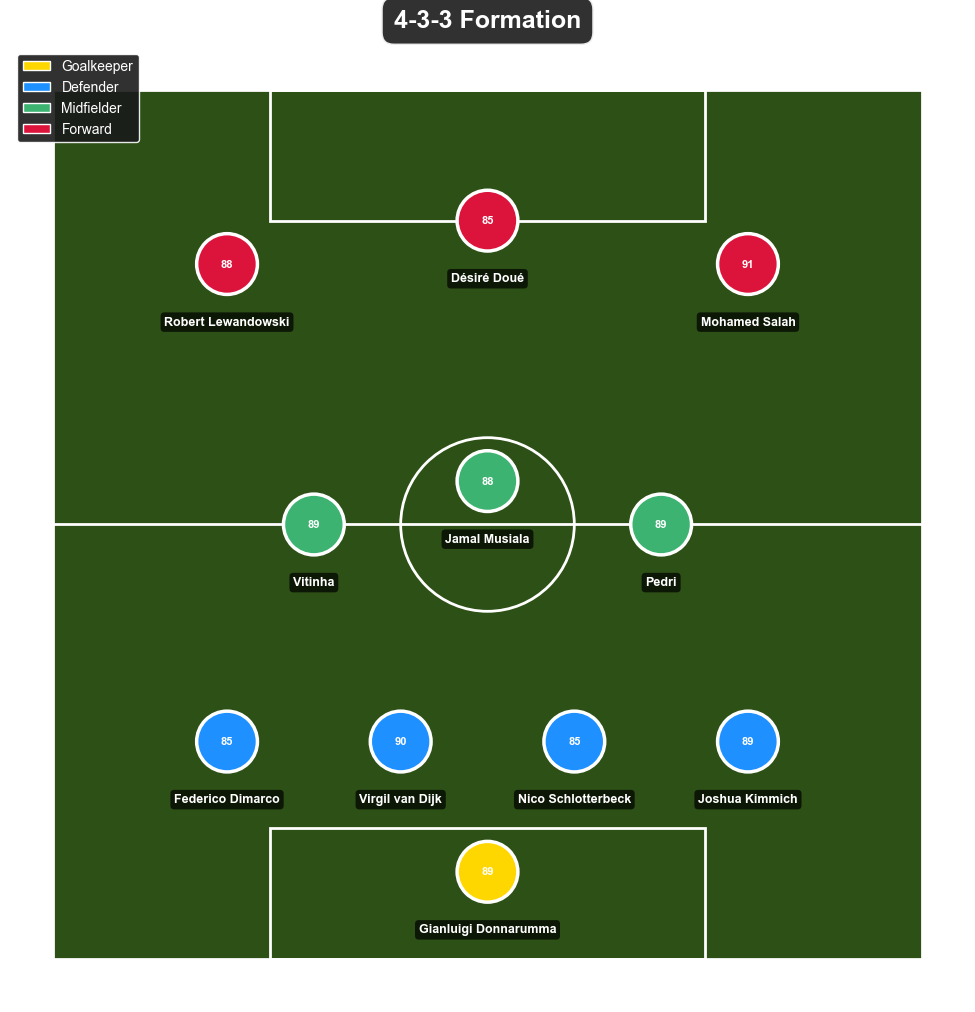

In [64]:
# Manually construct the above result and plot (due to time constraints)
optimal_dict = {'LW': {'name': 'Robert Lewandowski', 'group': 'FW'},
 'ST': {'name': 'Désiré Doué', 'group': 'FW'},
 'RW': {'name': 'Mohamed Salah', 'group': 'FW'},
 'CM': [{'name': 'Vitinha', 'group': 'MF'},
  {'name': 'Jamal Musiala', 'group': 'MF'},
  {'name': 'Pedri', 'group': 'MF'}],
 'LB': {'name': 'Federico Dimarco', 'group': 'DF'},
 'CB': [{'name': 'Virgil van Dijk', 'group': 'DF'},
  {'name': 'Nico Schlotterbeck', 'group': 'DF'}],
 'RB': {'name': 'Joshua Kimmich', 'group': 'DF'},
 'GK': {'name': 'Gianluigi Donnarumma', 'group': 'GK'}}

plot_formation(df_players, player_dict=optimal_dict)

## Limitations

Current model is quite simplistic and preliminary. It primarily relies on a lot of simplification assumptions and basic statistical indicators and does not account for important factors such as chemical compatibility between players, playing styles, tactical fit, or team dynamics. These elements often play a critical role in real-world team performance.